Autores: Josep Pérez Segura, Raul Rodríguez López Rey
# Tarea B3-T1


## 1. Importación de datos

Descargamos datos históricos de **8 criptoactivos** desde la API pública de Binance:

| # | Símbolo | Descripción |
|---|---------|-------------|
| 1 | BTCUSDT | Bitcoin |
| 2 | ETHUSDT | Ethereum |
| 3 | DOGEUSDT | Dogecoin |
| 4 | SOLUSDT | Solana |
| 5 | ADAUSDT | Cardano |
| 6 | XRPUSDT | Ripple |
| 7 | BNBUSDT | Binance Coin |
| 8 | AVAXUSDT | Avalanche |

- **Intervalo**: velas de 5 minutos
- **Periodo**: últimos ~4 años (marzo 2022 – marzo 2026)
- Los datos se cachean en CSV para evitar re-descargas.

In [1]:
%pip install requests pandas numpy matplotlib tqdm --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import datetime
import time
from pathlib import Path

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

pd.set_option("display.max_columns", None)

In [3]:
# --- Configuración ---
SYMBOLS = [
    "BTCUSDT",   # Bitcoin
    "ETHUSDT",   # Ethereum
    "DOGEUSDT",  # Dogecoin
    "SOLUSDT",   # Solana
    "ADAUSDT",   # Cardano
    "XRPUSDT",   # Ripple
    "BNBUSDT",   # Binance Coin
    "AVAXUSDT",  # Avalanche
]

INTERVAL = "5m"
BASE_URL = "https://api.binance.com/api/v3/klines"

START_DATE = datetime.datetime(2022, 3, 17)
END_DATE = datetime.datetime(2026, 3, 17)
START_MS = int(START_DATE.timestamp() * 1000)
END_MS = int(END_DATE.timestamp() * 1000)

LIMIT = 1000
SLEEP_BETWEEN = 0.05

DATA_DIR = Path("data")

print(f"Periodo: {START_DATE.date()} -> {END_DATE.date()}")
print(f"Intervalo: {INTERVAL}")
print(f"Activos: {len(SYMBOLS)}")
for s in SYMBOLS:
    print(f"  - {s}")

Periodo: 2022-03-17 -> 2026-03-17
Intervalo: 5m
Activos: 8
  - BTCUSDT
  - ETHUSDT
  - DOGEUSDT
  - SOLUSDT
  - ADAUSDT
  - XRPUSDT
  - BNBUSDT
  - AVAXUSDT


In [4]:
def fetch_klines(symbol, interval, start_ms, end_ms, limit=1000):
    """Descarga velas de Binance con paginación automática."""
    session = requests.Session()
    all_klines = []
    current_ms = start_ms

    # Estimar número de requests para la barra de progreso
    interval_ms = 5 * 60 * 1000  # 5 minutos en ms
    estimated_requests = (end_ms - start_ms) // (limit * interval_ms) + 1

    pbar = tqdm(total=estimated_requests, desc="Descargando velas")

    while current_ms < end_ms:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_ms,
            "endTime": end_ms,
            "limit": limit,
        }

        resp = session.get(BASE_URL, params=params)

        # Manejo de rate limiting
        if resp.status_code in (429, 418):
            retry_after = int(resp.headers.get("Retry-After", 5))
            print(f"Rate limited. Esperando {retry_after}s...")
            time.sleep(retry_after)
            continue

        resp.raise_for_status()
        data = resp.json()

        if not data:
            break

        all_klines.extend(data)

        # Avanzar: close_time del último registro + 1 ms
        current_ms = data[-1][6] + 1
        pbar.update(1)

        time.sleep(SLEEP_BETWEEN)

    pbar.close()
    print(f"Total velas descargadas: {len(all_klines):,}")
    return all_klines

In [5]:
# --- Descarga / carga de todos los activos ---
DATA_DIR.mkdir(exist_ok=True)

columns = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_volume", "num_trades",
    "taker_buy_base_vol", "taker_buy_quote_vol", "ignore",
]
numeric_cols = ["open", "high", "low", "close", "volume",
                "quote_volume", "taker_buy_base_vol", "taker_buy_quote_vol"]

dfs = {}  # diccionario {symbol: DataFrame}

for symbol in SYMBOLS:
    csv_path = DATA_DIR / f"{symbol}_{INTERVAL}_4y.csv"

    if csv_path.exists():
        print(f"[{symbol}] Cargando desde cache: {csv_path}")
        dfs[symbol] = pd.read_csv(csv_path, parse_dates=["open_time", "close_time"])
    else:
        print(f"[{symbol}] Descargando de Binance API...")
        raw = fetch_klines(symbol, INTERVAL, START_MS, END_MS, LIMIT)

        tmp = pd.DataFrame(raw, columns=columns)
        tmp[numeric_cols] = tmp[numeric_cols].astype(float)
        tmp["num_trades"] = tmp["num_trades"].astype(int)
        tmp["open_time"] = pd.to_datetime(tmp["open_time"], unit="ms")
        tmp["close_time"] = pd.to_datetime(tmp["close_time"], unit="ms")
        tmp.drop(columns=["ignore"], inplace=True)

        tmp.drop_duplicates(subset=["open_time"], inplace=True)
        tmp.sort_values("open_time", inplace=True)
        tmp.reset_index(drop=True, inplace=True)

        tmp = tmp[(tmp["open_time"] >= str(START_DATE)) &
                  (tmp["open_time"] < str(END_DATE))]
        tmp.reset_index(drop=True, inplace=True)

        tmp.to_csv(csv_path, index=False)
        size_mb = csv_path.stat().st_size / 1e6
        print(f"  -> Guardado: {csv_path} ({len(tmp):,} filas, {size_mb:.1f} MB)")

        dfs[symbol] = tmp

# df principal = BTCUSDT (compatibilidad con el resto del notebook)
df = dfs["BTCUSDT"]

print(f"\n{'='*60}")
print(f"Resumen de descarga:")
for sym, d in dfs.items():
    print(f"  {sym:10s} -> {d.shape[0]:>10,} filas | {d['open_time'].min().date()} - {d['open_time'].max().date()}")
print(f"{'='*60}")

[BTCUSDT] Descargando de Binance API...


Descargando velas:   0%|          | 0/421 [00:00<?, ?it/s]

Total velas descargadas: 420,753
  -> Guardado: data\BTCUSDT_5m_4y.csv (420,741 filas, 57.4 MB)
[ETHUSDT] Descargando de Binance API...


Descargando velas:   0%|          | 0/421 [00:00<?, ?it/s]

Total velas descargadas: 420,753
  -> Guardado: data\ETHUSDT_5m_4y.csv (420,741 filas, 54.3 MB)
[DOGEUSDT] Descargando de Binance API...


...

Total velas descargadas: 420,753
  -> Guardado: data\XRPUSDT_5m_4y.csv (420,741 filas, 50.4 MB)
[BNBUSDT] Descargando de Binance API...


Descargando velas:   0%|          | 0/421 [00:00<?, ?it/s]

Total velas descargadas: 420,753
  -> Guardado: data\BNBUSDT_5m_4y.csv (420,741 filas, 48.6 MB)
[AVAXUSDT] Descargando de Binance API...


Descargando velas:   0%|          | 0/421 [00:00<?, ?it/s]

Total velas descargadas: 420,753
  -> Guardado: data\AVAXUSDT_5m_4y.csv (420,741 filas, 46.6 MB)

Resumen de descarga:
  BTCUSDT    ->    420,741 filas | 2022-03-17 - 2026-03-16
  ETHUSDT    ->    420,741 filas | 2022-03-17 - 2026-03-16
  DOGEUSDT   ->    420,741 filas | 2022-03-17 - 2026-03-16
  SOLUSDT    ->    420,741 filas | 2022-03-17 - 2026-03-16
  ADAUSDT    ->    420,741 filas | 2022-03-17 - 2026-03-16
  XRPUSDT    ->    420,741 filas | 2022-03-17 - 2026-03-16
  BNBUSDT    ->    420,741 filas | 2022-03-17 - 2026-03-16
  AVAXUSDT   ->    420,741 filas | 2022-03-17 - 2026-03-16


In [6]:
# --- Verificación y exploración ---
for sym, d in dfs.items():
    print(f"\n{'─'*50}")
    print(f"  {sym}")
    print(f"  Periodo: {d['open_time'].min()} -> {d['open_time'].max()}")
    print(f"  Memoria: {d.memory_usage(deep=True).sum() / 1e6:.1f} MB")
    print(f"  Shape:   {d.shape}")

    deltas = d["open_time"].diff().dt.total_seconds().dropna()
    gaps = deltas[deltas != 300]
    print(f"  Huecos temporales (intervalos != 5 min): {len(gaps)} de {len(deltas)}")

print(f"\n{'─'*50}")
print("\nDetalle BTCUSDT (df principal):")
display(df.describe())
print()
display(df.head())


──────────────────────────────────────────────────
  BTCUSDT
  Periodo: 2022-03-17 00:00:00 -> 2026-03-16 23:00:00
  Memoria: 37.0 MB
  Shape:   (420741, 11)
  Huecos temporales (intervalos != 5 min): 1 de 420740

──────────────────────────────────────────────────
  ETHUSDT
  Periodo: 2022-03-17 00:00:00 -> 2026-03-16 23:00:00
  Memoria: 37.0 MB
  Shape:   (420741, 11)
  Huecos temporales (intervalos != 5 min): 1 de 420740

──────────────────────────────────────────────────
  DOGEUSDT
  Periodo: 2022-03-17 00:00:00 -> 2026-03-16 23:00:00
  Memoria: 37.0 MB
  Shape:   (420741, 11)
  Huecos temporales (intervalos != 5 min): 1 de 420740

──────────────────────────────────────────────────
  SOLUSDT
  Periodo: 2022-03-17 00:00:00 -> 2026-03-16 23:00:00
  Memoria: 37.0 MB
  Shape:   (420741, 11)
  Huecos temporales (intervalos != 5 min): 1 de 420740

──────────────────────────────────────────────────
  ADAUSDT
  Periodo: 2022-03-17 00:00:00 -> 2026-03-16 23:00:00
  Memoria: 37.0 MB
  Shape:

,open_time,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol
count,420741,420741.000000,420741.000000,420741.000000,420741.000000,420741.000000,420741,4.207410e+05,420741.000000,420741.000000,4.207410e+05
mean,2024-03-16 11:49:36.010895616,58067.312971,58118.219587,58015.456281,58067.390821,259.177131,2024-03-16 11:54:36.009851136,8.867506e+06,11453.970122,128.430261,4.374295e+06
min,2022-03-17 00:00:00,15590.570000,15633.310000,15476.000000,15593.580000,0.000000,2022-03-17 00:04:59.999000,0.000000e+00,0.000000,0.000000,0.000000e+00
25%,2023-03-17 05:25:00,27271.380000,27295.270000,27251.000000,27271.300000,41.531120,2023-03-17 05:29:59.999000064,2.460706e+06,3212.000000,18.686620,1.111383e+06
50%,2024-03-16 12:10:00,57597.390000,57666.670000,57526.430000,57598.000000,88.473020,2024-03-16 12:14:59.999000064,4.934646e+06,6883.000000,42.790700,2.370056e+06
75%,2025-03-16 17:35:00,88419.990000,88500.000000,88340.000000,88419.990000,253.395310,2025-03-16 17:39:59.999000064,1.043897e+07,14934.000000,126.852200,5.182153e+06
max,2026-03-16 23:00:00,126011.180000,126199.630000,125868.130000,126011.180000,15659.934840,2026-03-16 23:04:59.999000,5.588519e+08,711259.000000,8884.511430,2.663202e+08
std,NaN,32554.282300,32577.648982,32530.360047,32554.281763,488.448242,NaN,1.253312e+07,13133.882087,244.802471,6.375311e+06


,open_time,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol
0,2022-03-17 00:00:00,41114.01,41164.78,41080.00,41080.00,201.67630,2022-03-17 00:04:59.999,8.292936e+06,3444,118.41873,4.869273e+06
1,2022-03-17 00:05:00,41080.00,41092.67,40934.27,40965.73,177.05988,2022-03-17 00:09:59.999,7.263976e+06,3605,78.91125,3.237227e+06
2,2022-03-17 00:10:00,40965.73,41095.97,40962.42,40987.59,108.26700,2022-03-17 00:14:59.999,4.443245e+06,2885,56.27117,2.308982e+06
3,2022-03-17 00:15:00,40987.59,41041.00,40963.51,41024.00,62.70745,2022-03-17 00:19:59.999,2.571870e+06,1995,34.57253,1.417820e+06
4,2022-03-17 00:20:00,41024.00,41115.88,41004.66,41060.00,128.14071,2022-03-17 00:24:59.999,5.262165e+06,2443,74.30703,3.051519e+06


## 2. Barras alternativas: Dollar Bars, Volume Bars y Tick Bars

Las barras basadas en tiempo (time bars) presentan propiedades estadísticas indeseables: autocorrelación, heterocedasticidad y distribuciones no normales. Lopez de Prado (2018, Cap. 2) propone muestrear los datos usando **barras alternativas** que se cierran al alcanzar un umbral acumulado:

- **Tick Bars**: se cierra una barra cada N operaciones (trades). Muestrean según la actividad del mercado.
- **Volume Bars**: se cierra una barra cada V unidades de volumen (BTC). Normalizan la información por volumen negociado.
- **Dollar Bars**: se cierra una barra cada D dólares negociados (quote volume en USDT). Son las más robustas según MLdP, ya que normalizan por valor económico real.

Al usar velas de 5 min como proxy, cada vela aporta: `num_trades` (ticks), `volume` (BTC), y `quote_volume` (USDT). Acumulamos estos valores y generamos una nueva barra OHLCV cada vez que se supera el umbral.

Compararemos **3 umbrales distintos** para cada tipo de barra para ilustrar el efecto del parámetro.

In [7]:
def make_bars(df, metric_col, threshold):
    """
    Genera barras alternativas agrupando filas hasta que la suma acumulada
    de `metric_col` supera `threshold`.

    Parámetros:
        df: DataFrame con columnas open_time, open, high, low, close, volume,
            quote_volume, num_trades y la columna `metric_col`.
        metric_col: columna a acumular ('num_trades', 'volume', 'quote_volume').
        threshold: valor umbral para cerrar cada barra.

    Retorna:
        DataFrame con barras OHLCV + timestamp.
    """
    bars = []
    cum_metric = 0.0
    open_price = df.iloc[0]["open"]
    high_price = -np.inf
    low_price = np.inf
    cum_volume = 0.0
    cum_quote_volume = 0.0
    cum_trades = 0
    bar_start = df.iloc[0]["open_time"]

    for _, row in df.iterrows():
        high_price = max(high_price, row["high"])
        low_price = min(low_price, row["low"])
        cum_volume += row["volume"]
        cum_quote_volume += row["quote_volume"]
        cum_trades += row["num_trades"]
        cum_metric += row[metric_col]

        if cum_metric >= threshold:
            bars.append({
                "open_time": bar_start,
                "close_time": row["close_time"],
                "open": open_price,
                "high": high_price,
                "low": low_price,
                "close": row["close"],
                "volume": cum_volume,
                "quote_volume": cum_quote_volume,
                "num_trades": cum_trades,
            })
            # Reset
            cum_metric = 0.0
            cum_volume = 0.0
            cum_quote_volume = 0.0
            cum_trades = 0
            high_price = -np.inf
            low_price = np.inf
            open_price = row["close"]
            bar_start = row["close_time"]

    return pd.DataFrame(bars)

In [8]:
# --- Calcular estadísticas para elegir umbrales razonables ---
print("Estadísticas por vela de 5 min:")
print(f"  num_trades  -> media: {df['num_trades'].mean():,.0f}, mediana: {df['num_trades'].median():,.0f}")
print(f"  volume (BTC)-> media: {df['volume'].mean():,.1f}, mediana: {df['volume'].median():,.1f}")
print(f"  quote_vol ($)-> media: {df['quote_volume'].mean():,.0f}, mediana: {df['quote_volume'].median():,.0f}")

# Umbrales: elegidos para generar ~5K, ~15K y ~50K barras aprox.
total_trades = df["num_trades"].sum()
total_volume = df["volume"].sum()
total_dollar = df["quote_volume"].sum()

tick_thresholds = [
    int(total_trades / 50_000),
    int(total_trades / 15_000),
    int(total_trades / 5_000),
]
volume_thresholds = [
    round(total_volume / 50_000, 0),
    round(total_volume / 15_000, 0),
    round(total_volume / 5_000, 0),
]
dollar_thresholds = [
    round(total_dollar / 50_000, -3),
    round(total_dollar / 15_000, -3),
    round(total_dollar / 5_000, -3),
]

print(f"\nUmbrales Tick Bars:   {tick_thresholds} trades")
print(f"Umbrales Volume Bars: {volume_thresholds} BTC")
print(f"Umbrales Dollar Bars: {dollar_thresholds} USDT")

Estadísticas por vela de 5 min:
  num_trades  -> media: 11,454, mediana: 6,883
  volume (BTC)-> media: 259.2, mediana: 88.5
  quote_vol ($)-> media: 8,867,506, mediana: 4,934,646

Umbrales Tick Bars:   [96383, 321276, 963830] trades
Umbrales Volume Bars: [np.float64(2181.0), np.float64(7270.0), np.float64(21809.0)] BTC
Umbrales Dollar Bars: [np.float64(74618000.0), np.float64(248728000.0), np.float64(746185000.0)] USDT


In [9]:
# --- Generar las barras alternativas ---
print("Generando barras... (puede tardar unos segundos por cada umbral)\n")

bar_results = {}

for label, col, thresholds in [
    ("Tick Bars", "num_trades", tick_thresholds),
    ("Volume Bars", "volume", volume_thresholds),
    ("Dollar Bars", "quote_volume", dollar_thresholds),
]:
    bar_results[label] = {}
    for th in thresholds:
        bars_df = make_bars(df, col, th)
        bar_results[label][th] = bars_df
        print(f"  {label} (umbral={th:,.0f}): {len(bars_df):,} barras")
    print()

Generando barras... (puede tardar unos segundos por cada umbral)

  Tick Bars (umbral=96,383): 44,327 barras
  Tick Bars (umbral=321,276): 14,424 barras


KeyboardInterrupt: 

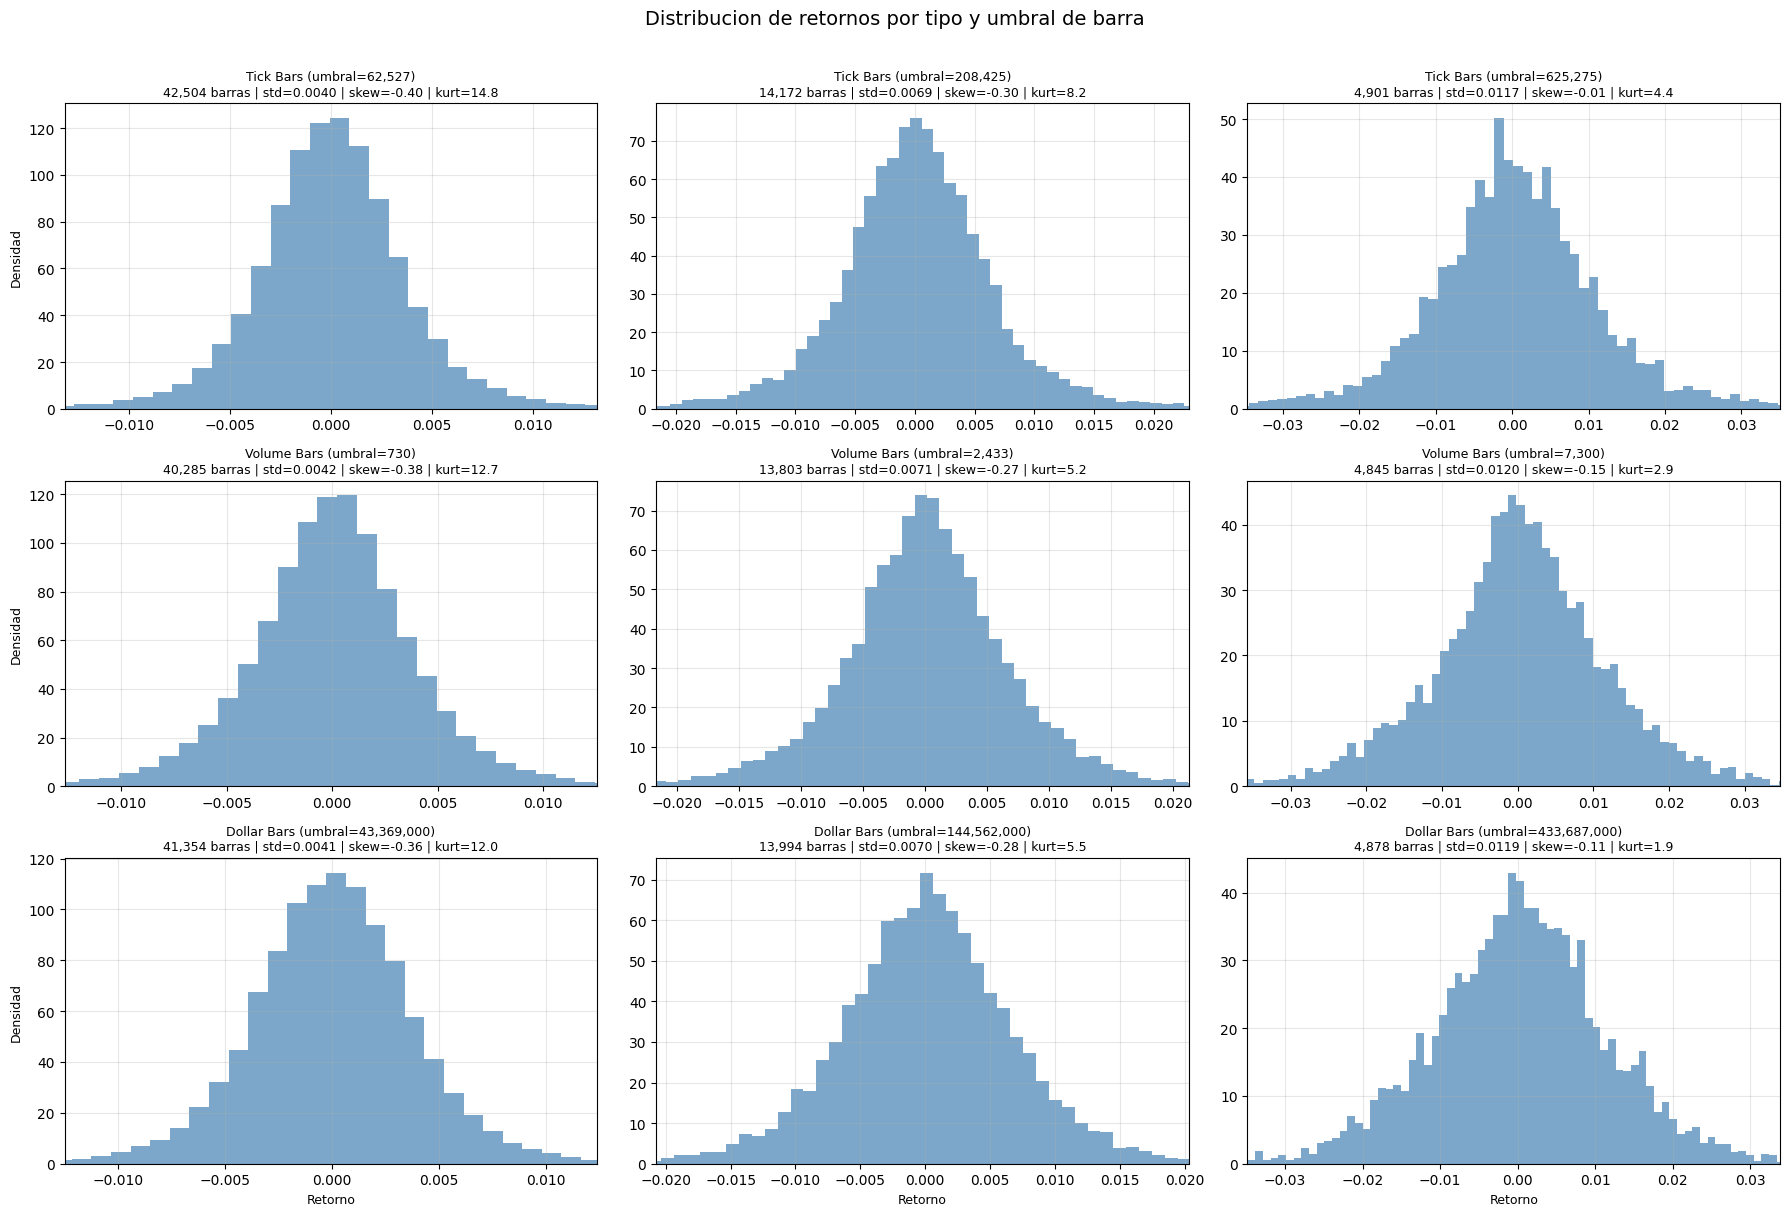

Resumen estadistico de retornos:
Tipo                     Umbral   N barras        Std     Skew     Kurt    AC(1)
---------------------------------------------------------------------------
Tick Bars                62,527     42,504     0.0040   -0.400     14.8  -0.0184
Tick Bars               208,425     14,172     0.0069   -0.300      8.2  -0.0202
Tick Bars               625,275      4,901     0.0117   -0.007      4.4  -0.0020
Volume Bars                 730     40,285     0.0042   -0.384     12.7  -0.0245
Volume Bars               2,433     13,803     0.0071   -0.268      5.2  -0.0076
Volume Bars               7,300      4,845     0.0120   -0.148      2.9  -0.0369
Dollar Bars          43,369,000     41,354     0.0041   -0.363     12.0  -0.0251
Dollar Bars         144,562,000     13,994     0.0070   -0.280      5.5  -0.0115
Dollar Bars         433,687,000      4,878     0.0119   -0.109      1.9  -0.0243


In [ ]:
# --- Grafica comparativa: retornos y autocorrelacion para cada tipo de barra ---
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    for col_idx, (th, bars_df) in enumerate(thresholds_dict.items()):
        ax = axes[row_idx, col_idx]
        returns = bars_df["close"].pct_change().dropna()
        ax.hist(returns, bins=150, alpha=0.7, density=True, color="steelblue", edgecolor="none")

        # Estadisticas en el titulo
        ax.set_title(
            f"{bar_type} (umbral={th:,.0f})\n"
            f"{len(bars_df):,} barras | "
            f"std={returns.std():.4f} | skew={returns.skew():.2f} | kurt={returns.kurtosis():.1f}",
            fontsize=9,
        )
        ax.set_xlim(returns.quantile(0.005), returns.quantile(0.995))
        ax.grid(True, alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel("Densidad", fontsize=9)
        if row_idx == 2:
            ax.set_xlabel("Retorno", fontsize=9)

fig.suptitle("Distribucion de retornos por tipo y umbral de barra", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Tabla resumen
print("Resumen estadistico de retornos:")
print(f"{'Tipo':<15} {'Umbral':>15} {'N barras':>10} {'Std':>10} {'Skew':>8} {'Kurt':>8} {'AC(1)':>8}")
print("-" * 75)
for bar_type, thresholds_dict in bar_results.items():
    for th, bars_df in thresholds_dict.items():
        r = bars_df["close"].pct_change().dropna()
        ac1 = r.autocorr(lag=1)
        print(f"{bar_type:<15} {th:>15,.0f} {len(bars_df):>10,} {r.std():>10.4f} {r.skew():>8.3f} {r.kurtosis():>8.1f} {ac1:>8.4f}")

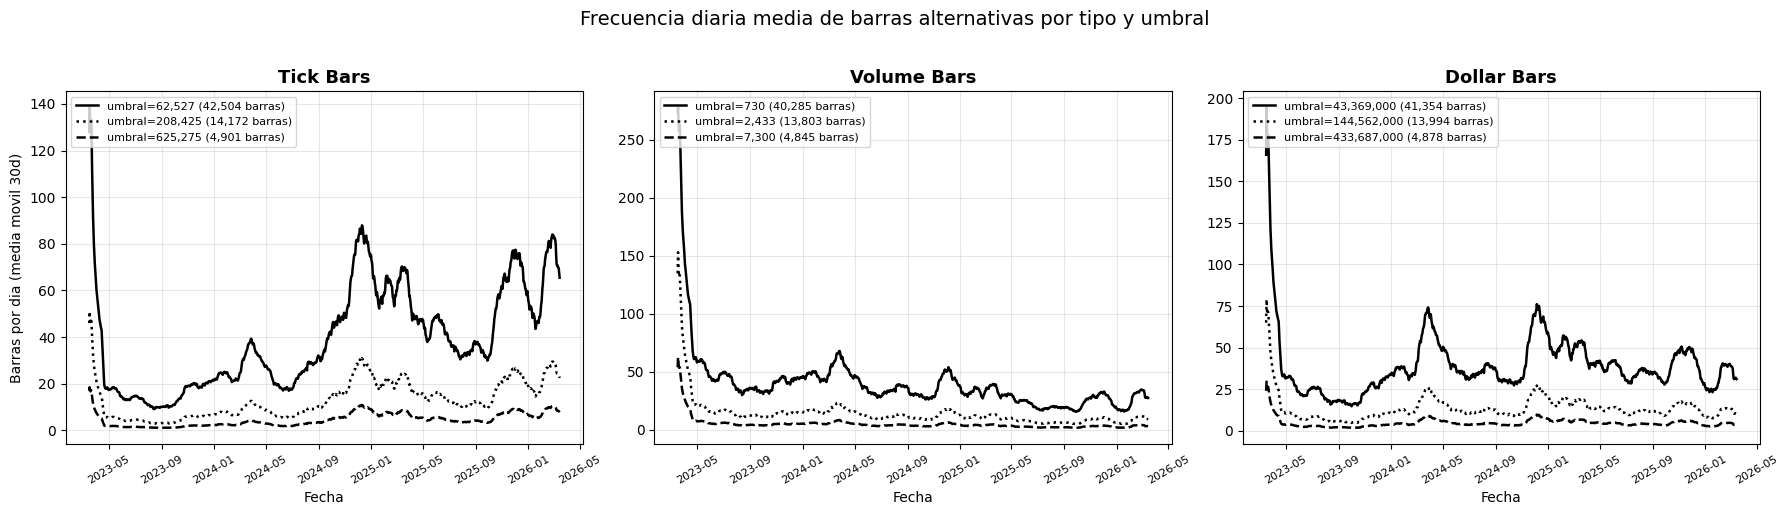

In [ ]:
# --- Frecuencia diaria media de cada tipo de barra (estilo MLdP Fig. 2.4) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

line_styles = ["-", ":", "--"]
colors_th = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for col_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[col_idx]
    for i, (th, bars_df) in enumerate(thresholds_dict.items()):
        bars_tmp = bars_df.copy()
        bars_tmp["date"] = pd.to_datetime(bars_tmp["open_time"]).dt.date
        daily_counts = bars_tmp.groupby("date").size()
        daily_counts.index = pd.to_datetime(daily_counts.index)
        rolling_freq = daily_counts.rolling(window=30, min_periods=1).mean()

        ax.plot(rolling_freq.index, rolling_freq.values,
                linestyle=line_styles[i],
                linewidth=1.8,
                color="black",
                label=f"umbral={th:,.0f} ({len(bars_df):,} barras)")

    ax.set_title(bar_type, fontsize=13, fontweight="bold")
    ax.set_xlabel("Fecha", fontsize=10)
    if col_idx == 0:
        ax.set_ylabel("Barras por dia (media movil 30d)", fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30, labelsize=8)

fig.suptitle("Frecuencia diaria media de barras alternativas por tipo y umbral", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

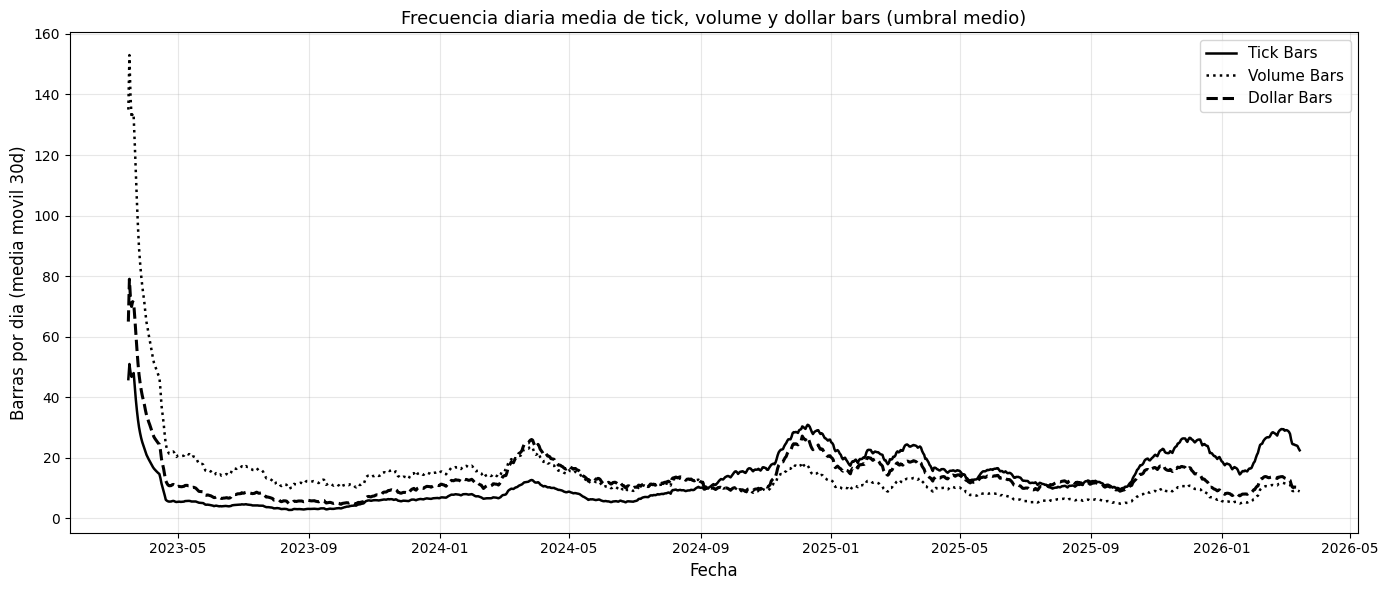

In [ ]:
# --- Frecuencia diaria media comparando los 3 tipos de barra (umbral medio, estilo MLdP Fig. 2.4) ---
fig, ax = plt.subplots(figsize=(14, 6))

line_styles = {"Tick Bars": "-", "Volume Bars": ":", "Dollar Bars": "--"}
line_widths = {"Tick Bars": 1.8, "Volume Bars": 1.8, "Dollar Bars": 2.2}

for bar_type, thresholds_dict in bar_results.items():
    # Usar umbral medio
    th_mid, bars_mid = list(thresholds_dict.items())[1]
    bars_mid = bars_mid.copy()
    bars_mid["date"] = pd.to_datetime(bars_mid["open_time"]).dt.date
    daily_counts = bars_mid.groupby("date").size()
    daily_counts.index = pd.to_datetime(daily_counts.index)
    rolling_freq = daily_counts.rolling(window=30, min_periods=1).mean()

    ax.plot(rolling_freq.index, rolling_freq.values,
            linestyle=line_styles[bar_type],
            linewidth=line_widths[bar_type],
            color="black",
            label=bar_type)

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Barras por dia (media movil 30d)", fontsize=12)
ax.set_title("Frecuencia diaria media de tick, volume y dollar bars (umbral medio)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

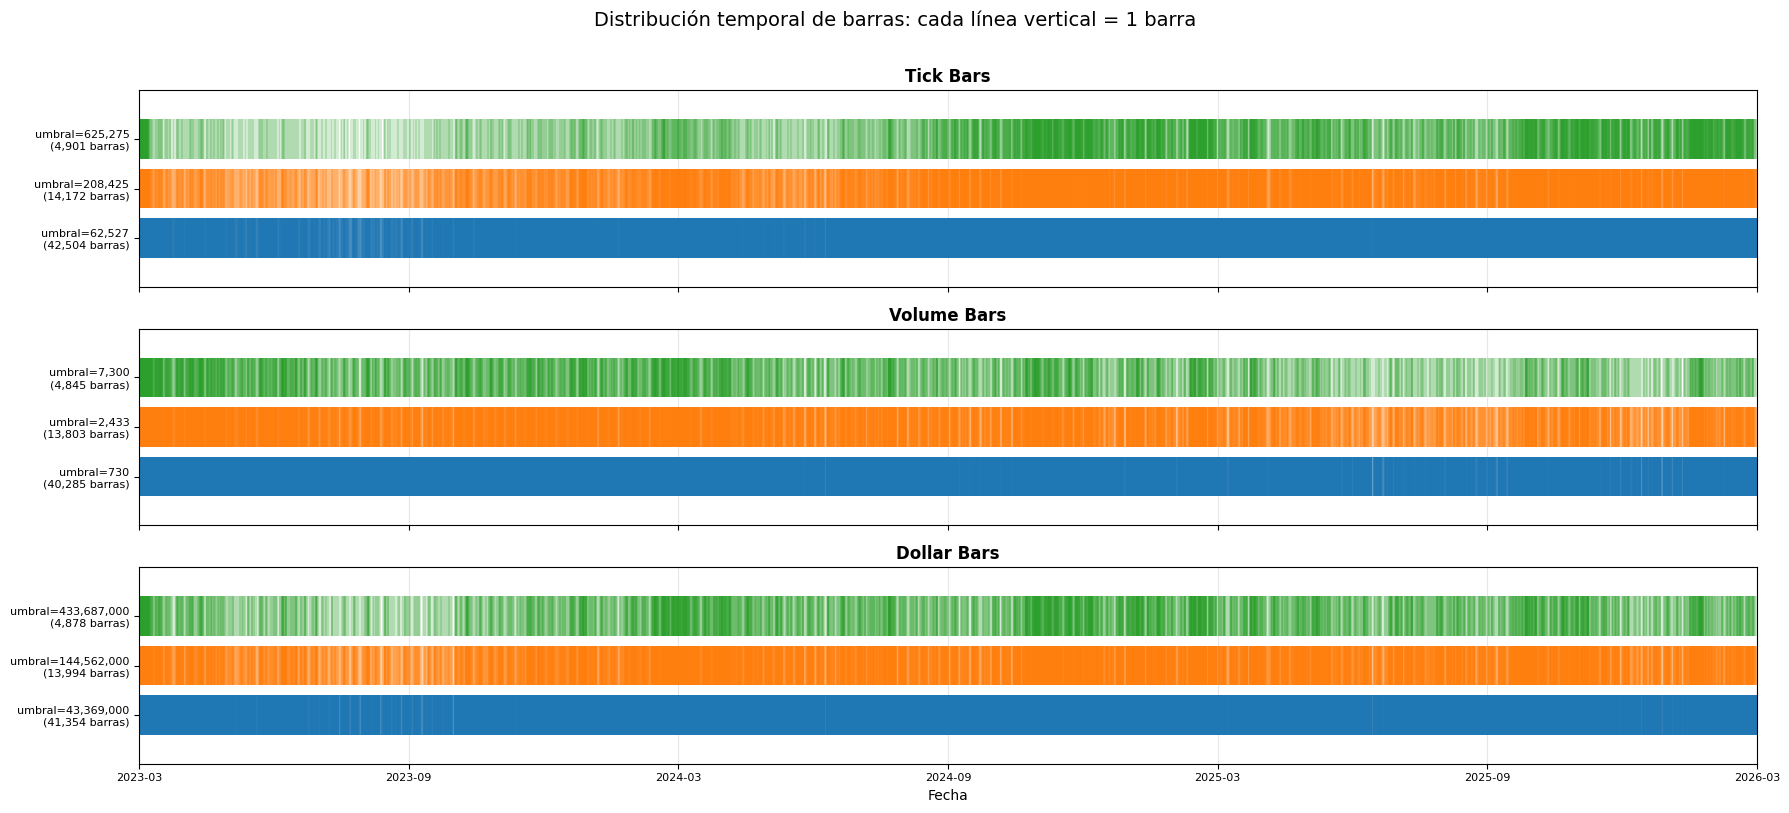

In [ ]:
# --- Event plot: marcas verticales en la línea temporal para cada barra ---
fig, axes = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for row_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[row_idx]
    th_list = list(thresholds_dict.items())
    for i, (th, bars_df) in enumerate(th_list):
        # Convertir timestamps a matplotlib dates
        times = bars_df["open_time"].values
        # eventplot espera valores numéricos
        times_num = pd.to_datetime(times).map(lambda x: x.timestamp())
        ax.eventplot(
            [times_num],
            lineoffsets=i,
            linelengths=0.8,
            linewidths=0.3,
            colors=[colors[i]],
        )
    ax.set_yticks(range(len(th_list)))
    ax.set_yticklabels([f"umbral={th:,.0f}\n({len(b):,} barras)" for th, b in th_list], fontsize=8)
    ax.set_title(bar_type, fontsize=12, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.3)

# Convertir eje x a fechas legibles
import matplotlib.dates as mdates
for ax in axes:
    # Reescalar eje x con fechas
    ax.set_xlim(
        pd.Timestamp(START_DATE).timestamp(),
        pd.Timestamp(END_DATE).timestamp(),
    )
    # Poner ticks con fechas
    xticks = pd.date_range(START_DATE, END_DATE, periods=7)
    ax.set_xticks([t.timestamp() for t in xticks])
    ax.set_xticklabels([t.strftime("%Y-%m") for t in xticks], fontsize=8)

axes[-1].set_xlabel("Fecha")
fig.suptitle("Distribución temporal de barras: cada línea vertical = 1 barra", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

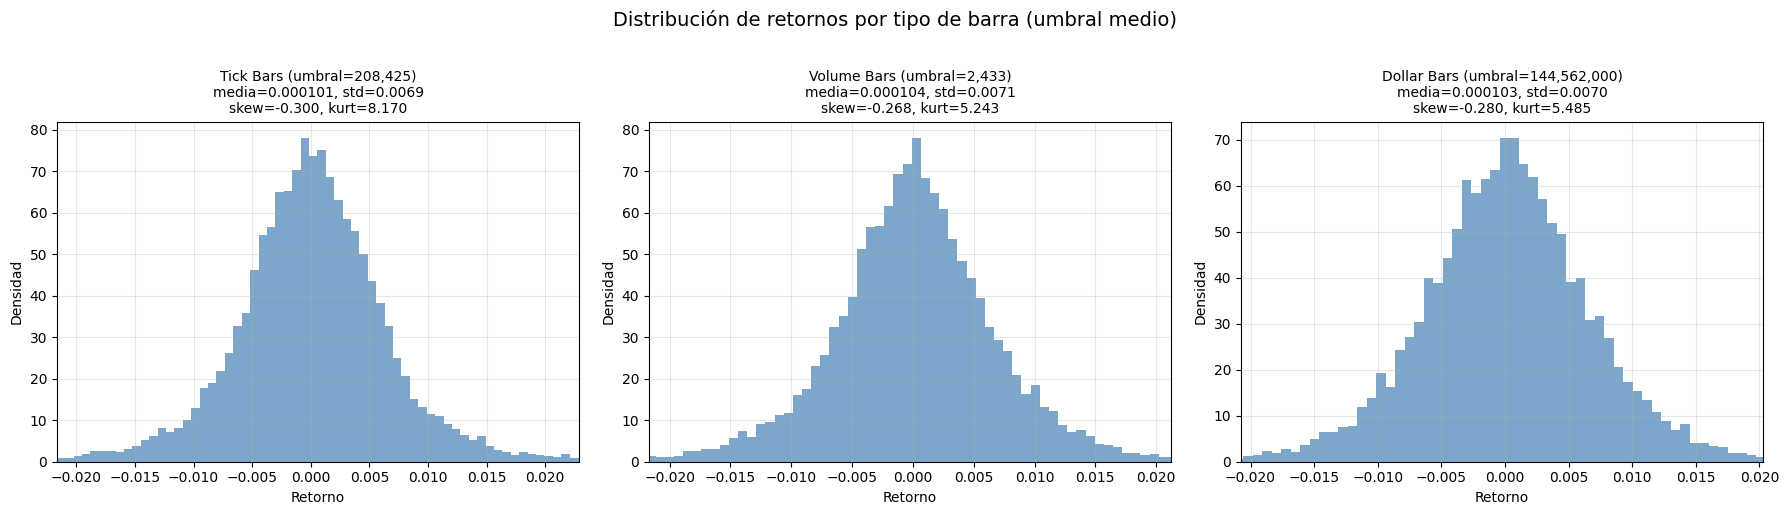


Resumen de retornos (umbral medio de cada tipo):
Tipo              N barras        Media        Std     Skew     Kurt
-----------------------------------------------------------------
Tick Bars           14,172     0.000101     0.0069   -0.300    8.170
Volume Bars         13,803     0.000104     0.0071   -0.268    5.243
Dollar Bars         13,994     0.000103     0.0070   -0.280    5.485


In [ ]:
# --- Comparar propiedades estadísticas: retornos de cada tipo de barra ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Usar el umbral medio de cada tipo para la comparación
for col_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[col_idx]
    thresholds_list = list(thresholds_dict.items())
    # Umbral medio
    th_mid, bars_mid = thresholds_list[1]
    returns = bars_mid["close"].pct_change().dropna()

    ax.hist(returns, bins=200, alpha=0.7, density=True, color="steelblue")
    ax.set_title(f"{bar_type} (umbral={th_mid:,.0f})\n"
                 f"media={returns.mean():.6f}, std={returns.std():.4f}\n"
                 f"skew={returns.skew():.3f}, kurt={returns.kurtosis():.3f}",
                 fontsize=10)
    ax.set_xlabel("Retorno")
    ax.set_ylabel("Densidad")
    ax.set_xlim(returns.quantile(0.005), returns.quantile(0.995))
    ax.grid(True, alpha=0.3)

fig.suptitle("Distribución de retornos por tipo de barra (umbral medio)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\nResumen de retornos (umbral medio de cada tipo):")
print(f"{'Tipo':<15} {'N barras':>10} {'Media':>12} {'Std':>10} {'Skew':>8} {'Kurt':>8}")
print("-" * 65)
for bar_type, thresholds_dict in bar_results.items():
    th_mid, bars_mid = list(thresholds_dict.items())[1]
    r = bars_mid["close"].pct_change().dropna()
    print(f"{bar_type:<15} {len(bars_mid):>10,} {r.mean():>12.6f} {r.std():>10.4f} {r.skew():>8.3f} {r.kurtosis():>8.3f}")

### Observaciones sobre las barras alternativas

**Efecto del umbral:** A mayor umbral, menos barras se generan y cada barra contiene más información agregada. Umbrales bajos producen más barras (mayor granularidad) pero con menor información por barra.

**Distribución temporal:** A diferencia de las time bars (espaciado fijo de 5 min), las barras alternativas tienen un espaciado temporal **variable**. Se generan más barras en periodos de alta actividad (volatilidad, noticias) y menos en periodos tranquilos. Esto es deseable porque muestrea proporcionalmente a la llegada de nueva información.

**Propiedades estadísticas de los retornos:**
- Las **Dollar Bars** tienden a producir retornos con menor autocorrelación serial y distribuciones más cercanas a la normalidad, ya que normalizan por el valor económico intercambiado.
- Las **Volume Bars** ofrecen un compromiso similar, normalizando por la cantidad de activo negociado.
- Las **Tick Bars** son las más simples conceptualmente, pero pueden ser sensibles a la fragmentación de órdenes.

Para las secciones siguientes, usaremos las **Dollar Bars** con el umbral medio como base, siguiendo la recomendación de Lopez de Prado.

In [ ]:
# --- Seleccionar Dollar Bars (umbral medio) para las siguientes secciones ---
dollar_mid_th = list(bar_results["Dollar Bars"].keys())[1]
df_bars = bar_results["Dollar Bars"][dollar_mid_th].copy()
df_bars.reset_index(drop=True, inplace=True)

print(f"Seleccionadas Dollar Bars con umbral = {dollar_mid_th:,.0f} USDT")
print(f"Total barras: {len(df_bars):,}")
display(df_bars.head())

Seleccionadas Dollar Bars con umbral = 144,562,000 USDT
Total barras: 13,994


,open_time,close_time,open,high,low,close,volume,quote_volume,num_trades
0,2023-03-16 00:00:00.000,2023-03-16 00:24:59.999,24285.66,24384.12,24200.00,24362.41,6938.26369,1.685274e+08,185917
1,2023-03-16 00:24:59.999,2023-03-16 00:49:59.999,24362.41,24373.11,24144.87,24234.44,7219.26477,1.750561e+08,190453
2,2023-03-16 00:49:59.999,2023-03-16 01:19:59.999,24234.44,24287.90,24123.00,24135.21,8163.38939,1.977509e+08,234634
3,2023-03-16 01:19:59.999,2023-03-16 01:44:59.999,24135.21,24324.86,24134.51,24263.56,6399.17638,1.551973e+08,180971
4,2023-03-16 01:44:59.999,2023-03-16 02:14:59.999,24263.56,24399.75,24222.33,24379.77,6403.53081,1.557652e+08,181741


## 3. Diferenciación fraccional

En series financieras existe un trade-off entre **estacionariedad** y **memoria**:

- Diferenciar con *d=1* (retornos) hace la serie estacionaria, pero destruye toda la memoria (relación con niveles pasados de precio).
- No diferenciar (*d=0*, precio en niveles) conserva la memoria, pero la serie es no estacionaria y viola supuestos de muchos modelos ML.

Lopez de Prado (2018, Cap. 5) propone la **diferenciación fraccional** con *0 < d < 1*, que permite encontrar el mínimo *d* que hace la serie estacionaria conservando la mayor cantidad de memoria posible.

La serie diferenciada fraccionalmente se obtiene aplicando el operador:

$$\tilde{X}_t = \sum_{k=0}^{\infty} w_k \, X_{t-k}, \quad w_k = -w_{k-1} \frac{d - k + 1}{k}$$

donde los pesos $w_k$ decaen lentamente (se truncan cuando $|w_k| < \tau$, con $\tau = 10^{-5}$ por defecto).

Compararemos varios valores de *d* ∈ {0, 0.2, 0.4, 0.6, 0.8, 1.0} y evaluaremos la estacionariedad con el test ADF.

In [ ]:
%pip install statsmodels --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\1jose\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


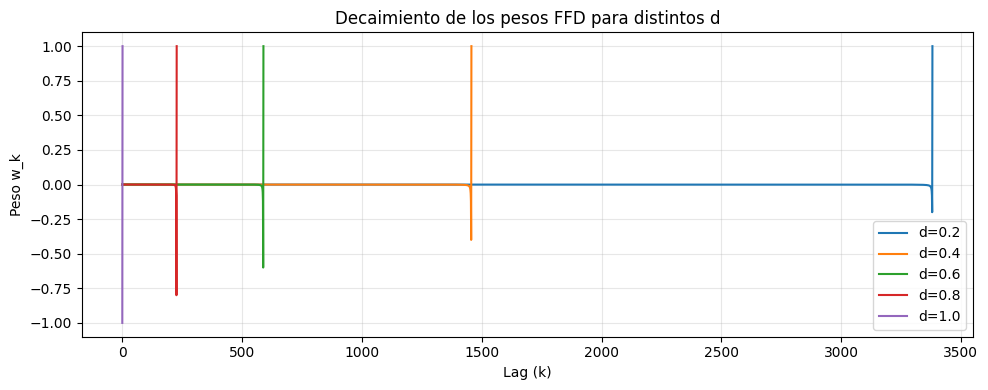

In [ ]:
from statsmodels.tsa.stattools import adfuller


def get_weights_ffd(d, threshold=1e-5):
    """
    Calcula los pesos para la diferenciación fraccional (Fixed-Width Window).
    Los pesos se truncan cuando |w_k| < threshold.
    (Lopez de Prado, 2018, Snippet 5.3)
    """
    w = [1.0]
    k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k)
        k += 1
    return np.array(w[::-1])


def frac_diff_ffd(series, d, threshold=1e-5):
    """
    Aplica diferenciación fraccional FFD a una serie.
    (Lopez de Prado, 2018, Snippet 5.4)
    
    Parámetros:
        series: pd.Series con los precios.
        d: orden de diferenciación fraccional.
        threshold: umbral para truncar pesos.
    
    Retorna:
        pd.Series con la serie diferenciada fraccionalmente.
    """
    weights = get_weights_ffd(d, threshold)
    width = len(weights)
    result = {}
    series_values = series.values

    for i in range(width - 1, len(series_values)):
        window = series_values[i - width + 1: i + 1]
        result[series.index[i]] = np.dot(weights, window)

    return pd.Series(result, dtype=float)


# Mostrar cómo decaen los pesos para distintos d
fig, ax = plt.subplots(figsize=(10, 4))
for d in [0.2, 0.4, 0.6, 0.8, 1.0]:
    w = get_weights_ffd(d, threshold=1e-5)
    ax.plot(range(len(w)), w, label=f"d={d}")
ax.set_xlabel("Lag (k)")
ax.set_ylabel("Peso w_k")
ax.set_title("Decaimiento de los pesos FFD para distintos d")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --- Aplicar diferenciación fraccional con varios d ---
d_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
close_series = df_bars["close"].reset_index(drop=True)

frac_diff_results = {}
for d in d_values:
    if d == 0.0:
        frac_diff_results[d] = close_series.copy()
    elif d == 1.0:
        frac_diff_results[d] = close_series.diff().dropna()
    else:
        frac_diff_results[d] = frac_diff_ffd(close_series, d)
    print(f"d={d:.1f}: {len(frac_diff_results[d]):,} valores")

d=0.0: 13,994 valores
d=0.2: 10,613 valores
d=0.4: 12,537 valores
d=0.6: 13,405 valores
d=0.8: 13,767 valores
d=1.0: 13,993 valores


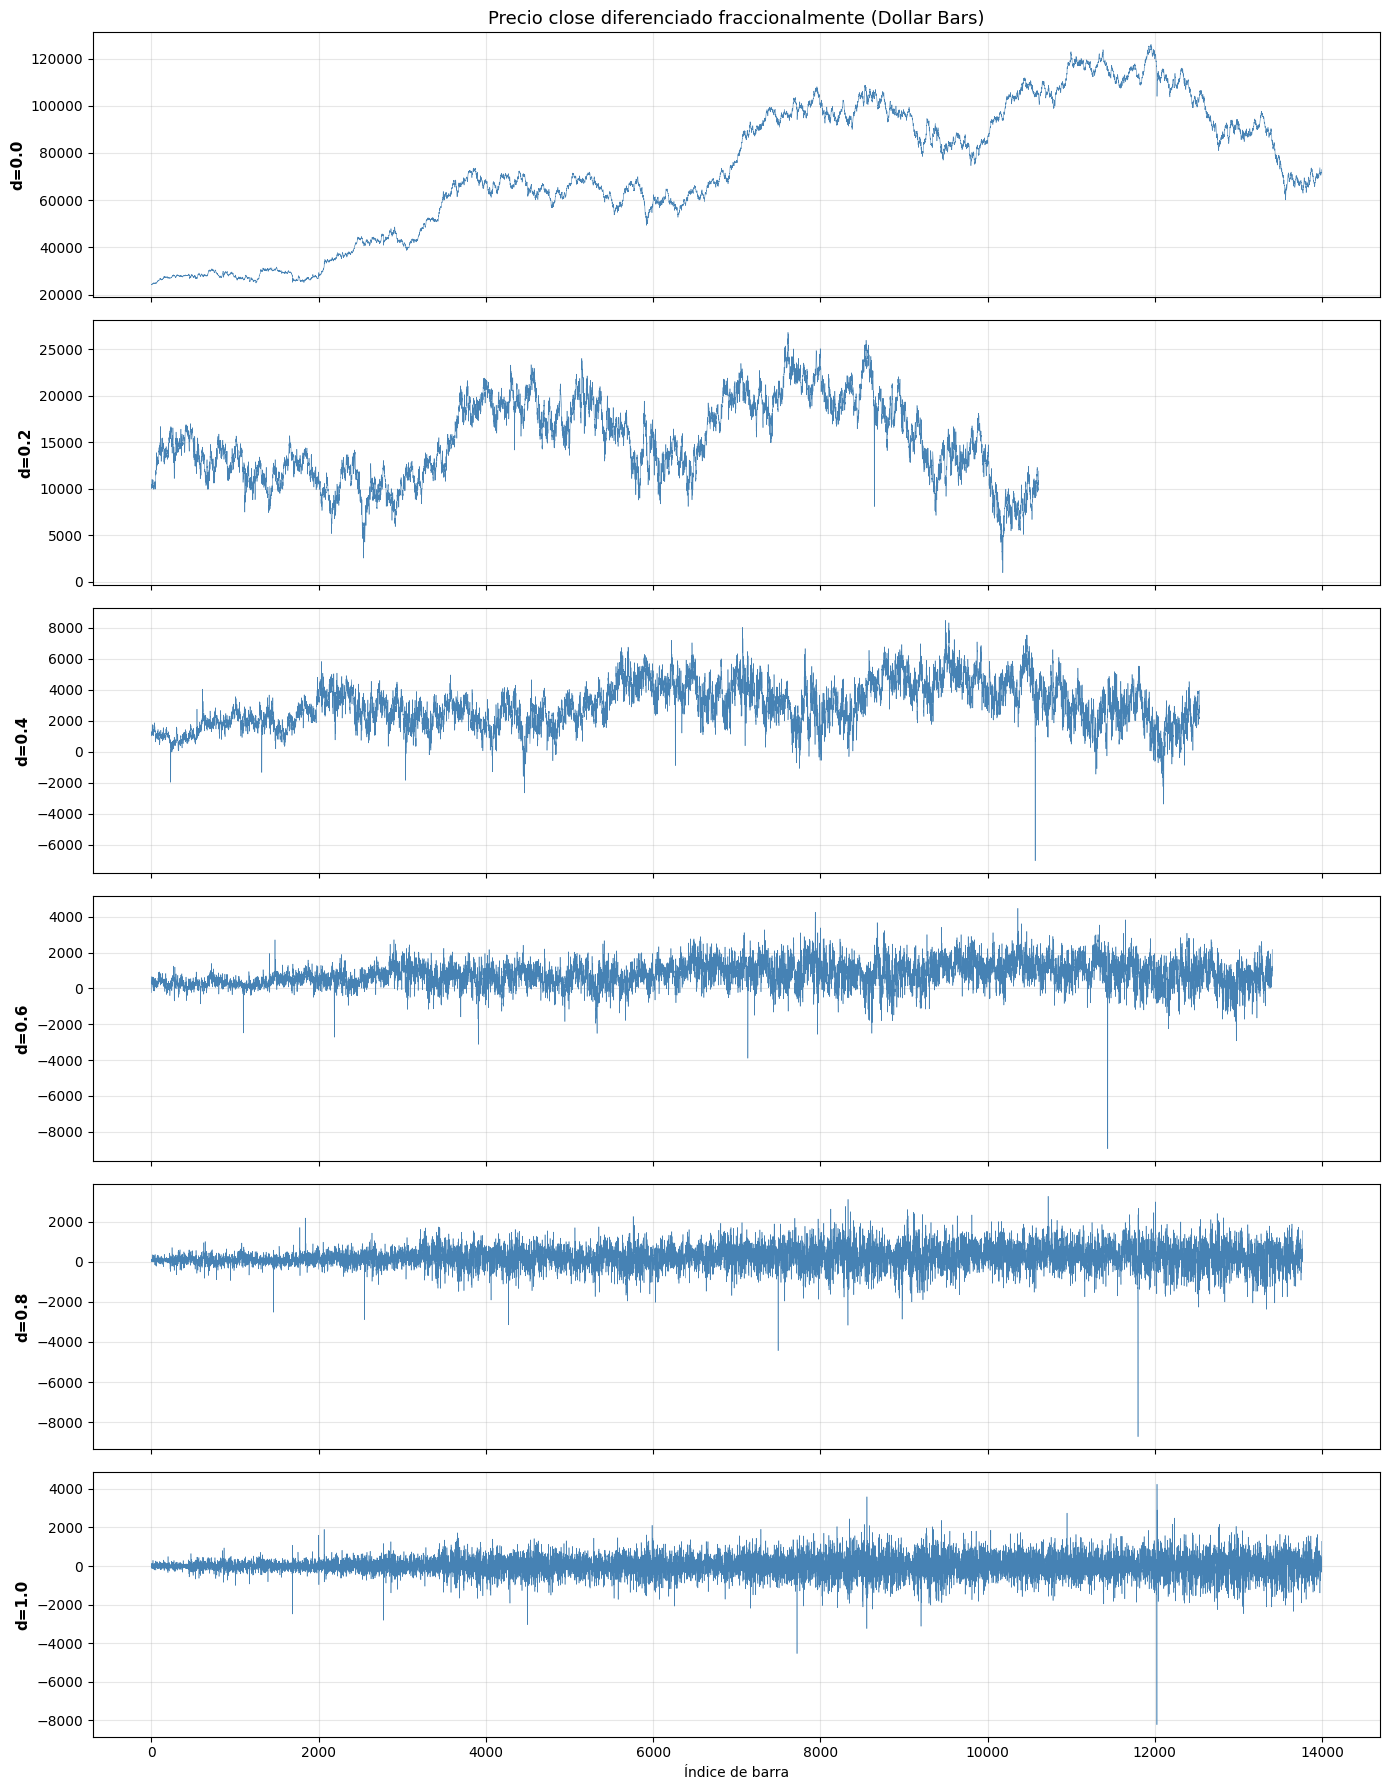

In [ ]:
# --- Gráfica: series diferenciadas fraccionalmente ---
fig, axes = plt.subplots(len(d_values), 1, figsize=(14, 3 * len(d_values)), sharex=True)

for i, d in enumerate(d_values):
    s = frac_diff_results[d]
    axes[i].plot(s.values, linewidth=0.4, color="steelblue")
    axes[i].set_ylabel(f"d={d:.1f}", fontsize=11, fontweight="bold")
    axes[i].grid(True, alpha=0.3)

axes[0].set_title("Precio close diferenciado fraccionalmente (Dollar Bars)", fontsize=13)
axes[-1].set_xlabel("Índice de barra")
plt.tight_layout()
plt.show()

In [ ]:
# --- Test ADF para cada d: evaluar estacionariedad ---
adf_results = []
for d in d_values:
    s = frac_diff_results[d].dropna()
    adf_stat, p_value, _, _, critical_values, _ = adfuller(s, maxlag=1)
    adf_results.append({
        "d": d,
        "ADF Statistic": adf_stat,
        "p-value": p_value,
        "Estacionaria (p<0.05)": "Sí" if p_value < 0.05 else "No",
        "1% CV": critical_values["1%"],
        "5% CV": critical_values["5%"],
    })

df_adf = pd.DataFrame(adf_results)
display(df_adf)

,d,ADF Statistic,p-value,Estacionaria (p<0.05),1% CV,5% CV
0,0.0,-1.774879,3.930027e-01,No,-3.430817,-2.861747
1,0.2,-6.024020,1.470562e-07,Sí,-3.430966,-2.861812
2,0.4,-17.790664,3.248294e-30,Sí,-3.430872,-2.861771
3,0.6,-40.460299,0.000000e+00,Sí,-3.430838,-2.861756
4,0.8,-64.640940,0.000000e+00,Sí,-3.430825,-2.861750
5,1.0,-120.046207,0.000000e+00,Sí,-3.430817,-2.861747


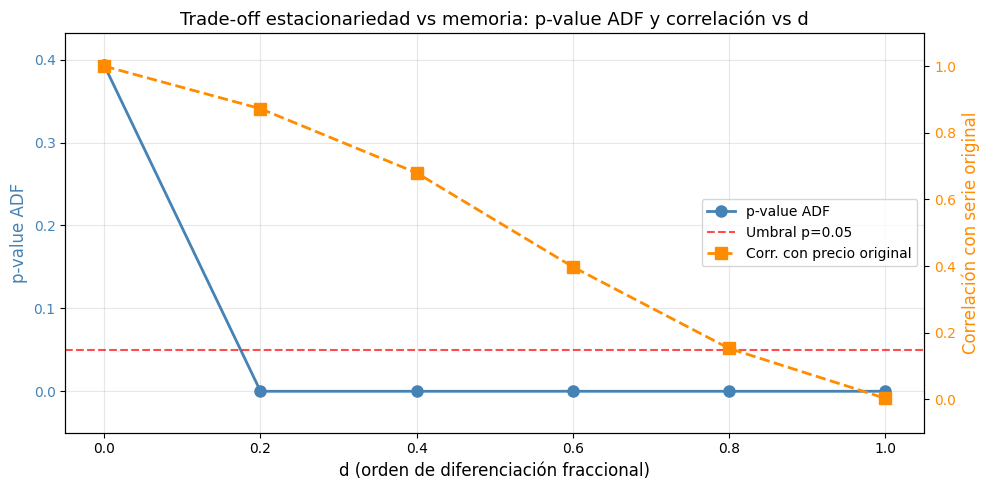


Mínimo d para estacionariedad (p < 0.05): d = 0.2
Correlación con precio original en d=0.2: 0.8724


In [ ]:
# --- Gráfica: p-value ADF vs d + correlación con serie original ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# p-value ADF
color_adf = "steelblue"
ax1.plot(df_adf["d"], df_adf["p-value"], "o-", color=color_adf, linewidth=2, markersize=8, label="p-value ADF")
ax1.axhline(0.05, color="red", linestyle="--", alpha=0.7, label="Umbral p=0.05")
ax1.set_xlabel("d (orden de diferenciación fraccional)", fontsize=12)
ax1.set_ylabel("p-value ADF", color=color_adf, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_adf)
ax1.set_ylim(-0.05, max(df_adf["p-value"].max() * 1.1, 0.1))

# Correlación con serie original (eje derecho)
ax2 = ax1.twinx()
color_corr = "darkorange"
correlations = []
for d in d_values:
    s = frac_diff_results[d].dropna()
    common_idx = close_series.index.intersection(s.index)
    corr = close_series.loc[common_idx].corr(s.loc[common_idx])
    correlations.append(corr)

ax2.plot(d_values, correlations, "s--", color=color_corr, linewidth=2, markersize=8, label="Corr. con precio original")
ax2.set_ylabel("Correlación con serie original", color=color_corr, fontsize=12)
ax2.tick_params(axis="y", labelcolor=color_corr)
ax2.set_ylim(-0.1, 1.1)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=10)

ax1.set_title("Trade-off estacionariedad vs memoria: p-value ADF y correlación vs d", fontsize=13)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Identificar d mínimo estacionario
d_min_stationary = df_adf.loc[df_adf["p-value"] < 0.05, "d"].min()
print(f"\nMínimo d para estacionariedad (p < 0.05): d = {d_min_stationary:.1f}")
print(f"Correlación con precio original en d={d_min_stationary:.1f}: {correlations[d_values.index(d_min_stationary)]:.4f}")

### Observaciones sobre la diferenciación fraccional

**Efecto del parámetro *d*:**
- Con **d=0** (precio en niveles), la serie no es estacionaria (p-value ADF alto), pero conserva toda la memoria (correlación = 1 con el precio original).
- Con **d=1** (retornos), la serie es estacionaria, pero pierde casi toda la relación con los niveles de precio (correlación baja).
- Valores intermedios como **d=0.2 o d=0.4** logran estacionariedad (p-value < 0.05) manteniendo una correlación significativa con la serie original. Este es el punto óptimo que busca MLdP.

**Gráfica de pesos FFD:** Los pesos para d pequeños decaen lentamente (memoria larga), mientras que para d→1 se concentran en los primeros lags (memoria corta). Esto explica visualmente por qué la diferenciación fraccional conserva más información del pasado.

**Recomendación:** Usar el **mínimo *d*** que logre estacionariedad como feature para modelos ML, en lugar de retornos simples (d=1).

## 4. Limpieza de matrices de covarianza ruidosa

Las matrices de covarianza empíricas contienen ruido debido a la naturaleza finita de las observaciones. Lopez de Prado (2020, *ML for Asset Managers*, Cap. 2) propone un método de **denoising** basado en la teoría de matrices aleatorias:

1. **Teorema de Marchenko-Pastur**: los eigenvalores de una matriz de correlación puramente aleatoria siguen una distribución conocida. Los eigenvalores que caen dentro de esta distribución se asocian con **ruido**.
2. **Fitting**: ajustamos σ² para encontrar el umbral λ+ que separa eigenvalores de ruido de los de señal.
3. **Denoising**: reemplazamos los eigenvalores de ruido por su media, preservando la traza de la matriz (método de eigenvalue residual constante, Snippet 2.5).

Construimos múltiples series de retornos a partir de las Dollar Bars usando ventanas rolling de distintos tamaños, y comparamos la matriz de correlación antes y después del denoising.

In [ ]:
%pip install scikit-learn scipy --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\1jose\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity


# --- Funciones de Marchenko-Pastur y denoising (MLdP 2020, Snippets 2.1-2.5) ---

def mp_pdf(var, q, pts=1000):
    """PDF de Marchenko-Pastur (Snippet 2.1)."""
    lambda_min = var * (1 - np.sqrt(1 / q)) ** 2
    lambda_max = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lambda_min, lambda_max, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt((lambda_max - x) * (x - lambda_min))
    pdf = np.maximum(pdf, 0)
    return x, pdf, lambda_max


def fit_kde(obs, bwidth=0.25, x=None):
    """Ajuste KDE a observaciones (Snippet 2.2)."""
    if len(obs.shape) == 1:
        obs = obs.reshape(-1, 1)
    kde = KernelDensity(kernel="gaussian", bandwidth=bwidth).fit(obs)
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    if len(x.shape) == 1:
        x = x.reshape(-1, 1)
    log_prob = kde.score_samples(x)
    pdf = np.exp(log_prob)
    return x.flatten(), pdf


def err_pdfs(var, evals, q, bwidth=0.25):
    """Error entre KDE empirica y MP teorica (Snippet 2.3)."""
    x_mp, pdf_mp, _ = mp_pdf(var, q, pts=1000)
    x_kde, pdf_kde = fit_kde(evals, bwidth, x=x_mp)
    sse = np.sum((pdf_kde - pdf_mp) ** 2)
    return sse


def find_max_eval(evals, q, bwidth=0.25):
    """Encuentra sigma^2 y lambda+ optimos (Snippet 2.4)."""
    result = minimize_scalar(err_pdfs, bounds=(1e-5, 1 - 1e-5),
                             args=(evals, q, bwidth), method="bounded")
    var = result.x
    _, _, lambda_max = mp_pdf(var, q)
    return var, lambda_max


def cov2corr(cov):
    """Convierte matriz de covarianza a correlacion."""
    std = np.sqrt(np.diag(cov))
    corr = cov / np.outer(std, std)
    corr[corr < -1] = -1
    corr[corr > 1] = 1
    return corr


def corr2cov(corr, std):
    """Convierte matriz de correlacion a covarianza."""
    return corr * np.outer(std, std)


def denoised_corr(evals, evecs, n_facts):
    """
    Denoising por eigenvalue residual constante (Snippet 2.5).
    Reemplaza eigenvalores de ruido por su media, preservando la traza.
    """
    evals_ = evals.copy()  # vector 1D de eigenvalores
    # Eigenvalores de ruido = los que no son senal
    evals_noise = evals_[n_facts:]
    # Reemplazar por media
    evals_[n_facts:] = np.mean(evals_noise)
    # Reconstruir correlacion: V @ diag(evals) @ V^T
    corr = evecs @ np.diag(evals_) @ evecs.T
    # Normalizar para que diagonal sea 1
    corr = cov2corr(corr)
    return corr


# --- Construir series de retornos con ventanas rolling ---
close = df_bars["close"].values
n_bars = len(close)

# Crear N features: retornos con distintos lookbacks
lookbacks = [5, 10, 20, 50, 100, 150, 200, 250, 300, 350,
             400, 450, 500, 600, 700, 800, 900, 1000]
returns_matrix = pd.DataFrame()
for lb in lookbacks:
    returns_matrix[f"ret_{lb}"] = pd.Series(close).pct_change(lb)

returns_matrix.dropna(inplace=True)
returns_matrix.reset_index(drop=True, inplace=True)

T, N = returns_matrix.shape
q = T / N
print(f"Matriz de retornos: T={T} observaciones, N={N} features, q=T/N={q:.1f}")

# Matriz de correlacion empirica
corr_emp = returns_matrix.corr().values
evals_raw, evecs_raw = np.linalg.eigh(corr_emp)
# Ordenar descendente
idx_sort = np.argsort(evals_raw)[::-1]
evals_raw = evals_raw[idx_sort]
evecs_raw = evecs_raw[:, idx_sort]

print(f"Eigenvalores: min={evals_raw.min():.4f}, max={evals_raw.max():.4f}")

# Encontrar sigma^2 y lambda+
var_opt, lambda_max = find_max_eval(evals_raw.reshape(-1, 1), q, bwidth=0.01)
n_signal = np.sum(evals_raw > lambda_max)
print(f"\nMarchenko-Pastur fitting:")
print(f"  sigma^2 = {var_opt:.4f}")
print(f"  lambda+ = {lambda_max:.4f}")
print(f"  Eigenvalores de senal: {n_signal} (> lambda+)")
print(f"  Eigenvalores de ruido: {N - n_signal}")

# Aplicar denoising
corr_denoised = denoised_corr(evals_raw, evecs_raw, n_signal)
evals_den, _ = np.linalg.eigh(corr_denoised)
evals_den = np.sort(evals_den)[::-1]

print(f"\nDespues del denoising:")
print(f"  Eigenvalores: min={evals_den.min():.4f}, max={evals_den.max():.4f}")

Matriz de retornos: T=12994 observaciones, N=18 features, q=T/N=721.9
Eigenvalores: min=0.0279, max=10.6360

Marchenko-Pastur fitting:
  sigma^2 = 1.0000
  lambda+ = 1.0758
  Eigenvalores de senal: 3 (> lambda+)
  Eigenvalores de ruido: 15

Despues del denoising:
  Eigenvalores: min=0.1830, max=10.3180


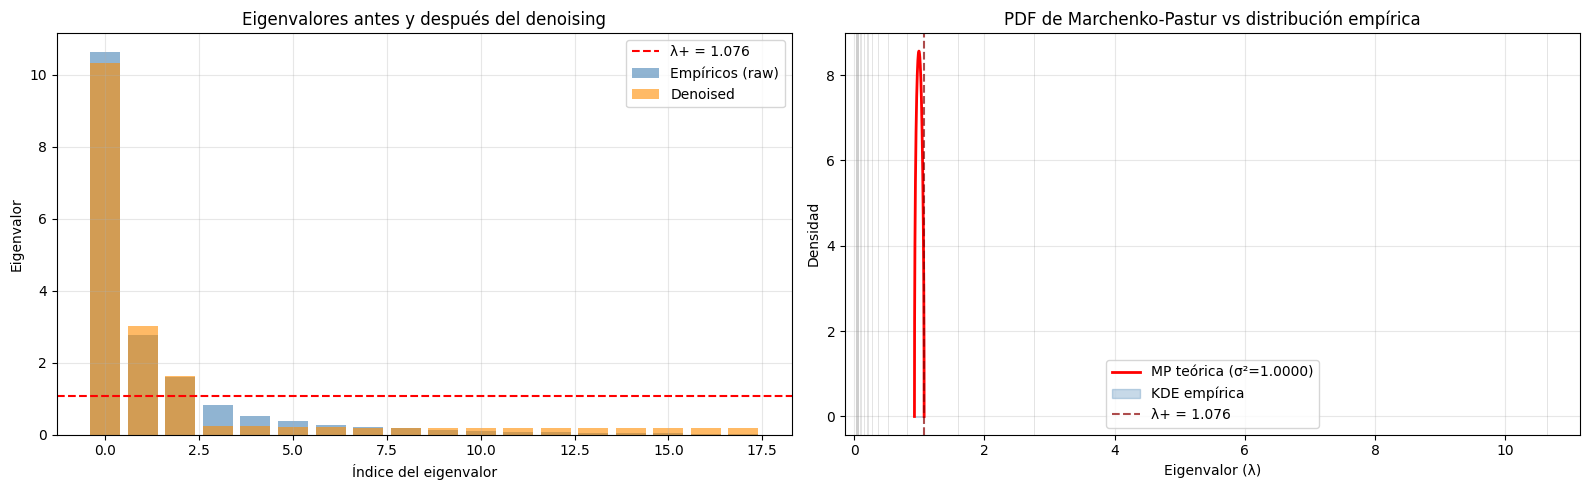

In [ ]:
# --- Gráfica 1: Eigenvalores antes/después + PDF Marchenko-Pastur ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izquierdo: eigenvalores
ax = axes[0]
ax.bar(range(N), evals_raw, alpha=0.6, label="Empíricos (raw)", color="steelblue")
ax.bar(range(N), evals_den, alpha=0.6, label="Denoised", color="darkorange")
ax.axhline(lambda_max, color="red", linestyle="--", linewidth=1.5, label=f"λ+ = {lambda_max:.3f}")
ax.set_xlabel("Índice del eigenvalor")
ax.set_ylabel("Eigenvalor")
ax.set_title("Eigenvalores antes y después del denoising")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel derecho: PDF Marchenko-Pastur vs empírica (KDE)
ax = axes[1]
x_mp, pdf_mp, _ = mp_pdf(var_opt, q, pts=1000)
ax.plot(x_mp, pdf_mp, color="red", linewidth=2, label=f"MP teórica (σ²={var_opt:.4f})")
x_kde, pdf_kde = fit_kde(evals_raw.reshape(-1, 1), bwidth=0.01, x=x_mp)
ax.fill_between(x_kde, pdf_kde, alpha=0.3, color="steelblue", label="KDE empírica")
ax.axvline(lambda_max, color="darkred", linestyle="--", alpha=0.7, label=f"λ+ = {lambda_max:.3f}")
# Marcar eigenvalores individuales
for ev in evals_raw:
    ax.axvline(ev, color="gray", alpha=0.3, linewidth=0.5)
ax.set_xlabel("Eigenvalor (λ)")
ax.set_ylabel("Densidad")
ax.set_title("PDF de Marchenko-Pastur vs distribución empírica")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

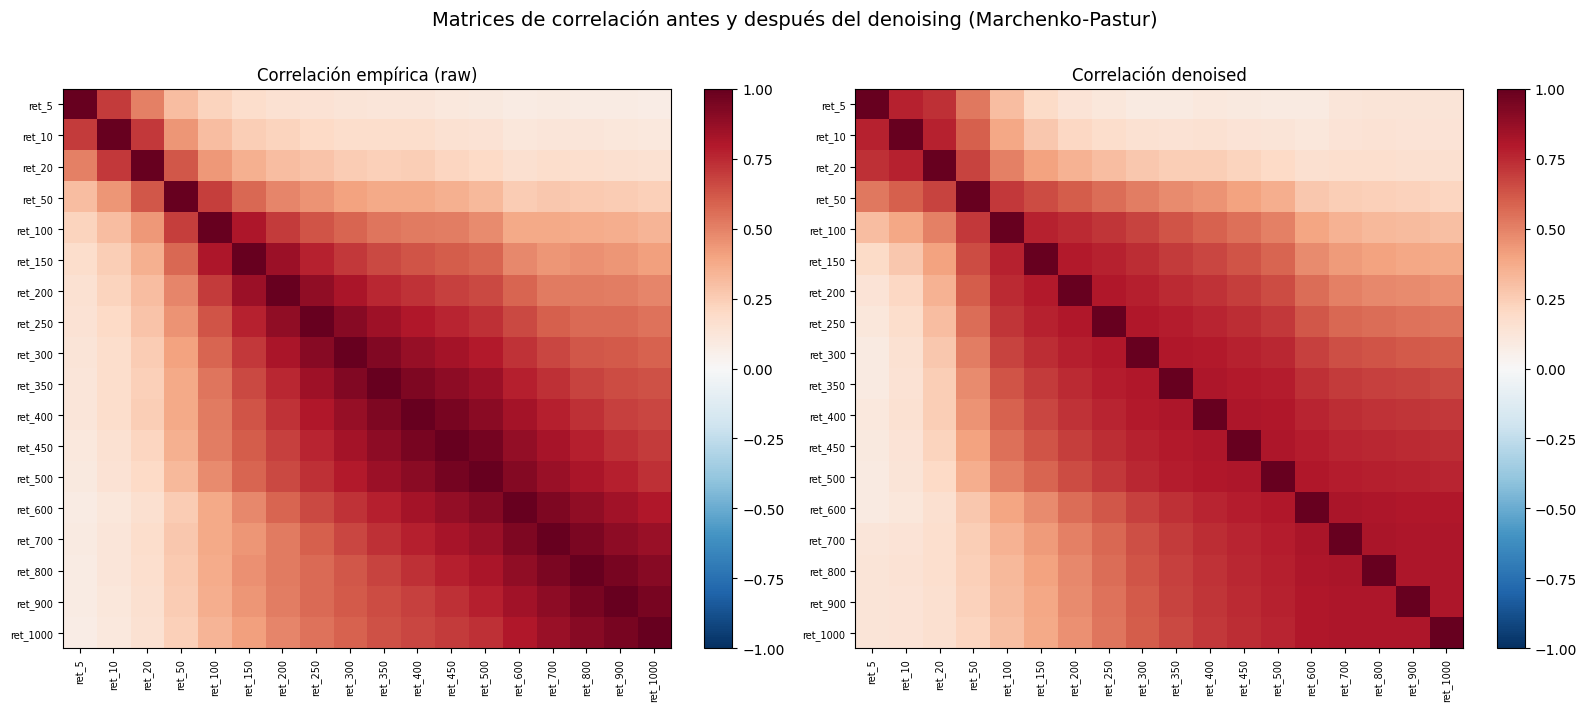

Diferencia máxima absoluta: 0.2249
Diferencia media absoluta: 0.0435


In [ ]:
# --- Gráfica 2: Heatmaps de correlación antes y después ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

labels = [f"ret_{lb}" for lb in lookbacks]

ax = axes[0]
im0 = ax.imshow(corr_emp, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_title("Correlación empírica (raw)", fontsize=12)
ax.set_xticks(range(N))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticks(range(N))
ax.set_yticklabels(labels, fontsize=7)
plt.colorbar(im0, ax=ax, fraction=0.046)

ax = axes[1]
im1 = ax.imshow(corr_denoised, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_title("Correlación denoised", fontsize=12)
ax.set_xticks(range(N))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticks(range(N))
ax.set_yticklabels(labels, fontsize=7)
plt.colorbar(im1, ax=ax, fraction=0.046)

fig.suptitle("Matrices de correlación antes y después del denoising (Marchenko-Pastur)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Diferencia
diff = corr_denoised - corr_emp
print(f"Diferencia máxima absoluta: {np.abs(diff).max():.4f}")
print(f"Diferencia media absoluta: {np.abs(diff).mean():.4f}")

### Observaciones sobre el denoising de covarianza

**Marchenko-Pastur fitting:** El teorema de Marchenko-Pastur predice la distribución de eigenvalores de una matriz de correlación generada por datos puramente aleatorios. Los eigenvalores por debajo de λ+ se consideran ruido.

**Efecto del denoising:**
- Los eigenvalores de ruido (por debajo de λ+) se reemplazan por su media, eliminando las fluctuaciones espurias.
- Los eigenvalores de señal (por encima de λ+) se preservan intactos.
- La traza de la matriz se conserva (suma de eigenvalores = N), garantizando que la matriz resultante siga siendo una matriz de correlación válida.

**Aplicación práctica:** Usar la matriz de correlación denoised en lugar de la empírica mejora la estabilidad de modelos de optimización de carteras, reducción de dimensionalidad (PCA) y estimación de riesgo, ya que elimina relaciones espurias causadas por el tamaño finito de la muestra.

## 5. Triple barrera con varios thresholds

Lopez de Prado (2018, Cap. 3) propone el método de **triple barrera** para etiquetar observaciones financieras. Cada evento tiene tres posibles resultados:

1. **Barrera superior (profit taking)**: el precio sube más de `pt × σ` antes de que expire la barrera vertical.
2. **Barrera inferior (stop loss)**: el precio baja más de `sl × σ` antes de que expire la barrera vertical.
3. **Barrera vertical (tiempo máximo)**: ninguna de las barreras horizontales se toca antes del tiempo límite.

El target dinámico σ se estima como la **volatilidad rolling** (desviación estándar de retornos en una ventana exponencial), siguiendo el Snippet 3.1 del libro.

Probaremos varias combinaciones de `[pt, sl]` y ventanas de barrera vertical para analizar cómo afectan a la distribución de etiquetas {-1, 0, +1}.

In [ ]:
# --- Funciones de triple barrera (MLdP 2018, Cap. 3, Snippets 3.1-3.5) ---

def get_daily_vol(close, span=100):
    """
    Volatilidad rolling como proxy del target dinamico (Snippet 3.1).
    Usa media exponencial de retornos absolutos.
    """
    ret = close.pct_change()
    vol = ret.ewm(span=span).std()
    return vol


def apply_triple_barrier(close, events, pt_sl):
    """
    Aplica las tres barreras a cada evento (Snippet 3.2).
    
    close: pd.Series indexada por enteros.
    events: DataFrame con 't1' (int, indice barrera vertical) y 'trgt' (float).
    pt_sl: [pt_mult, sl_mult].
    
    Retorna DataFrame con 'pt' y 'sl' (indices int donde se tocan, o NaN).
    """
    pt_mult, sl_mult = pt_sl
    close_vals = close.values
    n = len(close_vals)

    pt_hits = np.full(len(events), np.nan)
    sl_hits = np.full(len(events), np.nan)

    event_locs = events.index.values
    event_t1 = events["t1"].values.astype(int)
    event_trgt = events["trgt"].values

    for i in range(len(events)):
        loc = event_locs[i]
        t1 = min(event_t1[i], n - 1)
        if loc >= n:
            continue

        path_slice = close_vals[loc:t1 + 1]
        if len(path_slice) == 0:
            continue
        path_ret = path_slice / close_vals[loc] - 1.0

        # Profit taking
        if pt_mult > 0:
            pt_val = event_trgt[i] * pt_mult
            hits = np.where(path_ret >= pt_val)[0]
            if len(hits) > 0:
                pt_hits[i] = loc + hits[0]

        # Stop loss
        if sl_mult > 0:
            sl_val = -event_trgt[i] * sl_mult
            hits = np.where(path_ret <= sl_val)[0]
            if len(hits) > 0:
                sl_hits[i] = loc + hits[0]

    out = events[["t1"]].copy()
    out["pt"] = pt_hits
    out["sl"] = sl_hits
    return out


def get_events(close, t_events, pt_sl, trgt, min_ret, num_bars):
    """
    Genera eventos con triple barrera (Snippet 3.3).
    """
    # Barrera vertical: t1
    t1 = pd.Series(t_events + num_bars, index=t_events)
    t1 = t1.clip(upper=close.index[-1])

    # Target: filtrar por min_ret
    trgt_ = trgt.reindex(t_events).dropna()
    trgt_ = trgt_[trgt_ > min_ret]

    # Construir DataFrame de eventos solo para indices validos
    common_idx = trgt_.index
    events = pd.DataFrame({"t1": t1.reindex(common_idx), "trgt": trgt_}, index=common_idx)

    # Aplicar barreras
    barriers = apply_triple_barrier(close, events, pt_sl)
    return barriers


def get_bins(barriers, close):
    """
    Etiqueta eventos segun la primera barrera tocada (Snippet 3.5).
    Retorna {-1, 0, +1}.
    """
    close_vals = close.values
    n = len(close_vals)
    
    locs = barriers.index.values
    t1_vals = barriers["t1"].values.astype(int)
    pt_vals = barriers["pt"].values.astype(float)
    sl_vals = barriers["sl"].values.astype(float)

    labels = np.zeros(len(barriers), dtype=int)
    rets = np.zeros(len(barriers), dtype=float)

    for i in range(len(barriers)):
        loc = locs[i]
        t1 = min(t1_vals[i], n - 1)
        pt_idx = pt_vals[i]
        sl_idx = sl_vals[i]

        has_pt = not np.isnan(pt_idx)
        has_sl = not np.isnan(sl_idx)

        if has_sl and has_pt:
            if sl_idx <= pt_idx:
                label = -1
                first_touch = int(sl_idx)
            else:
                label = 1
                first_touch = int(pt_idx)
        elif has_sl:
            label = -1
            first_touch = int(sl_idx)
        elif has_pt:
            label = 1
            first_touch = int(pt_idx)
        else:
            # Barrera vertical: signo del retorno
            ret_at_t1 = close_vals[t1] / close_vals[loc] - 1 if t1 < n else 0
            label = int(np.sign(ret_at_t1))
            first_touch = t1

        first_touch = min(first_touch, n - 1)
        labels[i] = label
        rets[i] = close_vals[first_touch] / close_vals[loc] - 1

    out = pd.DataFrame({"t1": t1_vals, "label": labels, "ret": rets}, index=barriers.index)
    return out


# --- Preparar datos ---
close_bars = df_bars["close"].reset_index(drop=True)
vol = get_daily_vol(close_bars, span=100)

# Eventos: cada barra es un evento potencial (empezando desde la barra 100 para tener volatilidad)
t_events = pd.Index(range(100, len(close_bars) - 50))

# Configuraciones de [pt, sl] y ventanas verticales
pt_sl_configs = [
    ([1, 1], "pt=1, sl=1 (simetrico)"),
    ([2, 2], "pt=2, sl=2 (simetrico amplio)"),
    ([1, 2], "pt=1, sl=2 (sl mas holgado)"),
]
vertical_windows = [10, 25, 50]

print(f"Total barras: {len(close_bars):,}")
print(f"Eventos a evaluar: {len(t_events):,}")
print(f"Configuraciones: {len(pt_sl_configs)} x {len(vertical_windows)} ventanas = {len(pt_sl_configs) * len(vertical_windows)} combinaciones")

# Calcular todas las combinaciones
all_results = {}
for (pt_sl, config_name) in pt_sl_configs:
    for vw in vertical_windows:
        key = f"{config_name}\nV={vw} barras"
        print(f"  Procesando: {config_name}, V={vw}...", end=" ")
        barriers = get_events(close_bars, t_events, pt_sl, vol, min_ret=1e-5, num_bars=vw)
        bins = get_bins(barriers, close_bars)
        all_results[key] = bins
        counts = bins["label"].value_counts().sort_index()
        print(f"-> {len(bins)} eventos etiquetados: {dict(counts)}")

Total barras: 13,994
Eventos a evaluar: 13,844
Configuraciones: 3 x 3 ventanas = 9 combinaciones
  Procesando: pt=1, sl=1 (simetrico), V=10... -> 13844 eventos etiquetados: {-1: np.int64(6702), 1: np.int64(7142)}
  Procesando: pt=1, sl=1 (simetrico), V=25... -> 13844 eventos etiquetados: {-1: np.int64(6710), 1: np.int64(7134)}
  Procesando: pt=1, sl=1 (simetrico), V=50... -> 13844 eventos etiquetados: {-1: np.int64(6710), 1: np.int64(7134)}
  Procesando: pt=2, sl=2 (simetrico amplio), V=10... -> 13844 eventos etiquetados: {-1: np.int64(6692), 1: np.int64(7152)}
  Procesando: pt=2, sl=2 (simetrico amplio), V=25... -> 13844 eventos etiquetados: {-1: np.int64(6645), 1: np.int64(7199)}
  Procesando: pt=2, sl=2 (simetrico amplio), V=50... -> 13844 eventos etiquetados: {-1: np.int64(6628), 1: np.int64(7216)}
  Procesando: pt=1, sl=2 (sl mas holgado), V=10... -> 13844 eventos etiquetados: {-1: np.int64(5294), 1: np.int64(8550)}
  Procesando: pt=1, sl=2 (sl mas holgado), V=25... -> 13844 event

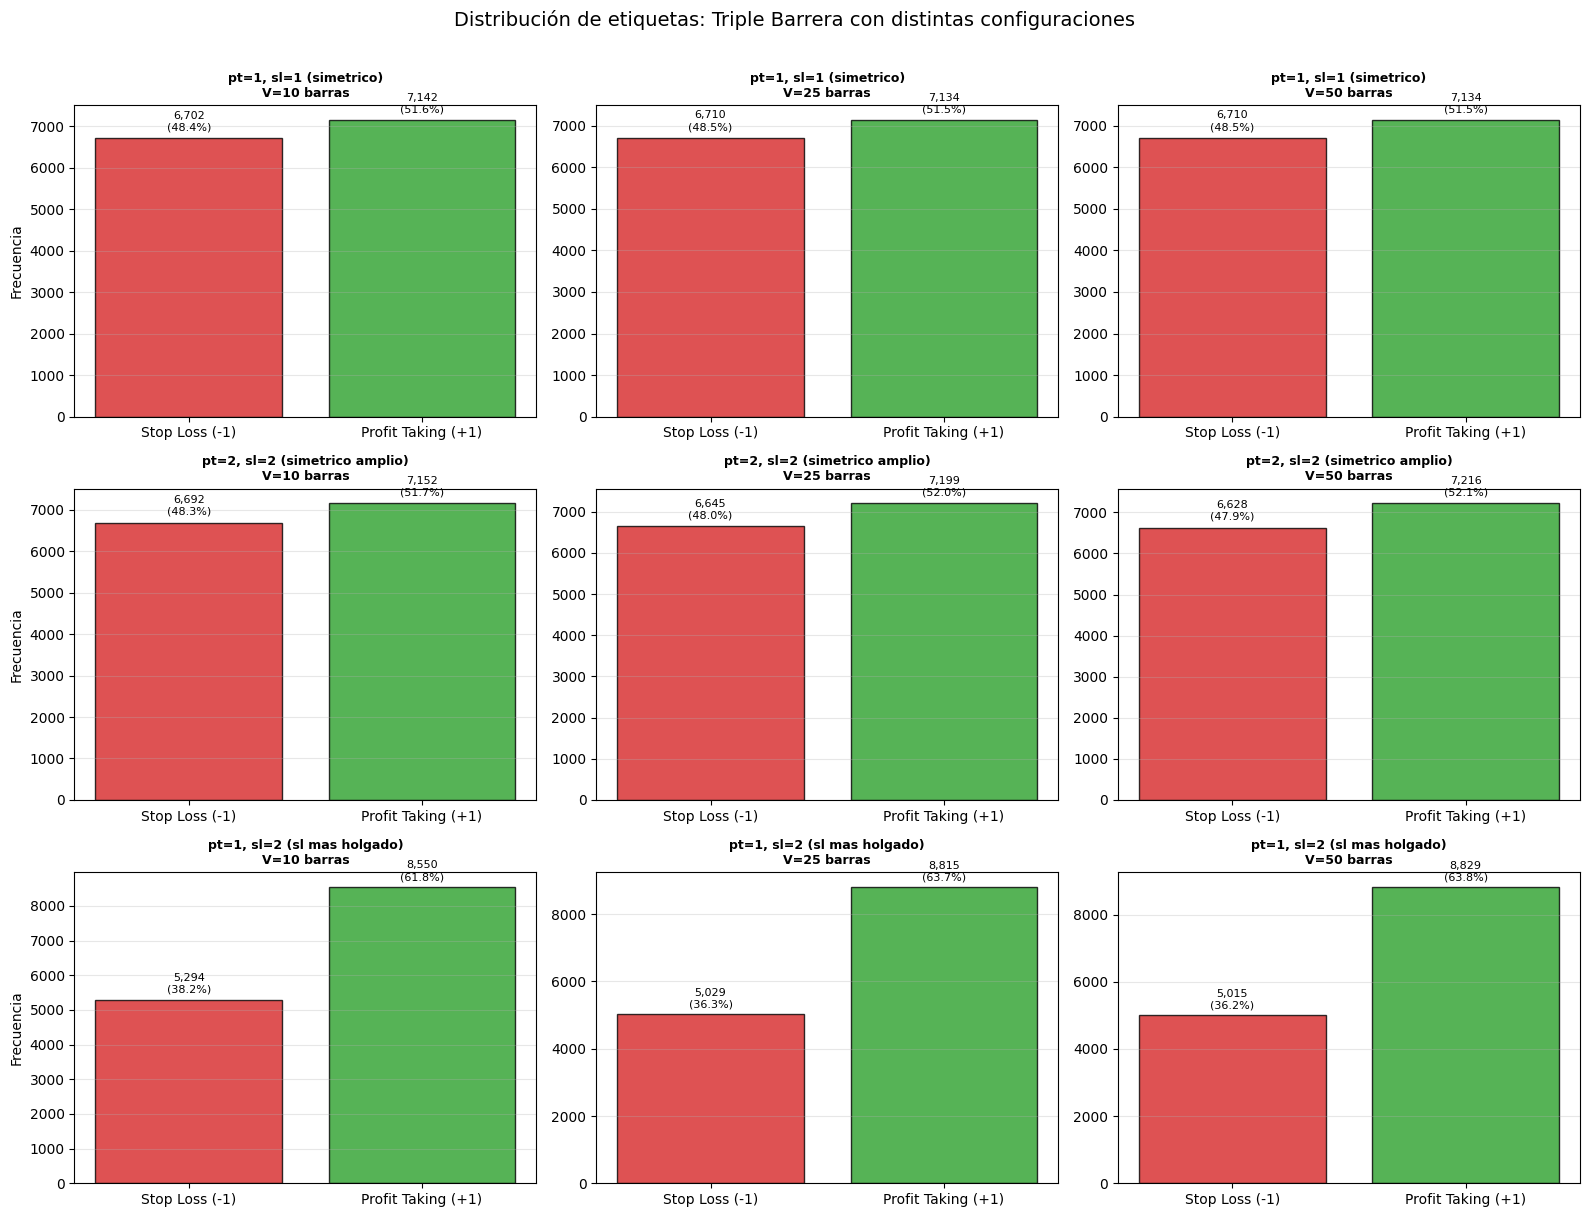

In [ ]:
# --- Gráfica 3x3: distribución de etiquetas para cada combinación ---
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

keys = list(all_results.keys())
colors_label = {-1: "#d62728", 0: "#7f7f7f", 1: "#2ca02c"}
label_names = {-1: "Stop Loss (-1)", 0: "Vertical (0)", 1: "Profit Taking (+1)"}

for idx, key in enumerate(keys):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    bins = all_results[key]
    counts = bins["label"].value_counts().sort_index()

    bars_plot = ax.bar(
        [label_names.get(k, str(k)) for k in counts.index],
        counts.values,
        color=[colors_label.get(k, "gray") for k in counts.index],
        alpha=0.8,
        edgecolor="black",
    )

    total = counts.sum()
    for bar, val in zip(bars_plot, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
                f"{val:,}\n({val/total*100:.1f}%)", ha="center", va="bottom", fontsize=8)

    ax.set_title(key, fontsize=9, fontweight="bold")
    ax.set_ylabel("Frecuencia" if col == 0 else "")
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Distribución de etiquetas: Triple Barrera con distintas configuraciones", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

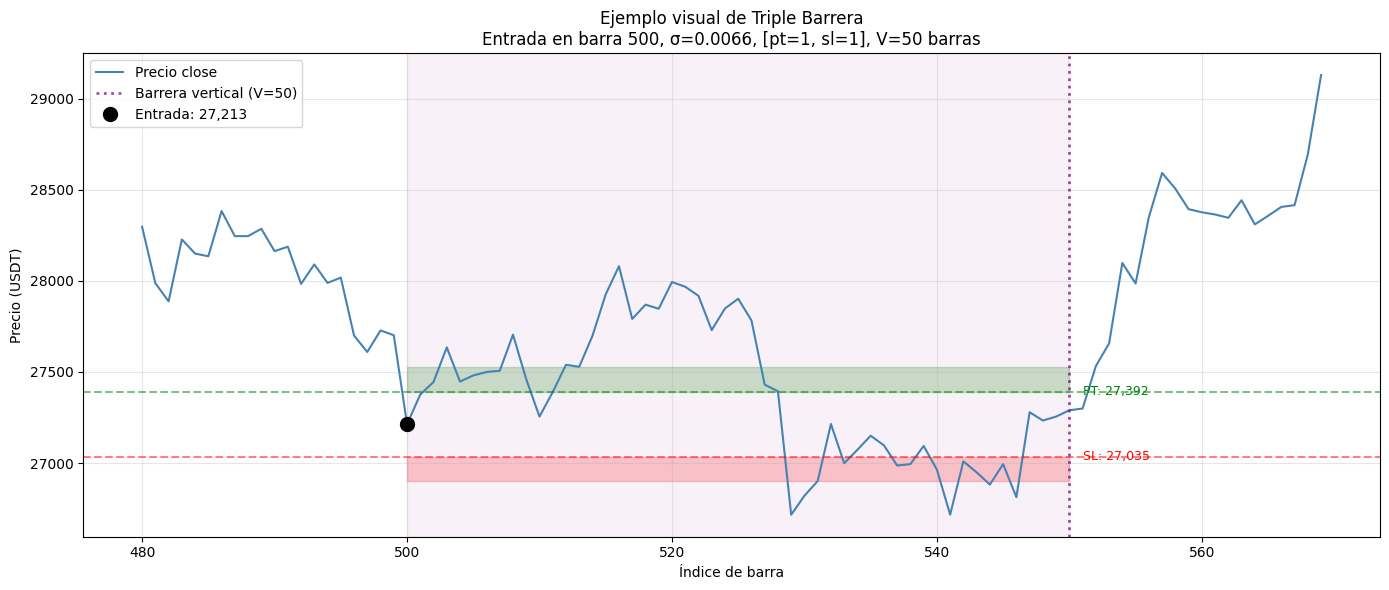

In [ ]:
# --- Ejemplo visual de las 3 barreras sobre el precio ---
# Elegimos un evento concreto para visualizar las 3 barreras
example_idx = 500  # barra de ejemplo
vw_example = 50
pt_sl_example = [1, 1]

# Calcular volatilidad en el punto
vol_at_idx = vol.iloc[example_idx]
price_at_idx = close_bars.iloc[example_idx]

# Rango de visualización
start_vis = max(0, example_idx - 20)
end_vis = min(len(close_bars), example_idx + vw_example + 20)

fig, ax = plt.subplots(figsize=(14, 6))

# Precio
x_range = range(start_vis, end_vis)
ax.plot(x_range, close_bars.iloc[start_vis:end_vis].values, color="steelblue", linewidth=1.5, label="Precio close")

# Barrera superior (profit taking)
pt_price = price_at_idx * (1 + pt_sl_example[0] * vol_at_idx)
ax.axhline(pt_price, xmin=0, xmax=1, color="green", linestyle="--", alpha=0.5)
ax.fill_between(range(example_idx, example_idx + vw_example + 1),
                pt_price, pt_price * 1.005, color="green", alpha=0.2)
ax.text(example_idx + vw_example + 1, pt_price, f"PT: {pt_price:,.0f}", color="green", fontsize=9, va="center")

# Barrera inferior (stop loss)
sl_price = price_at_idx * (1 - pt_sl_example[1] * vol_at_idx)
ax.axhline(sl_price, xmin=0, xmax=1, color="red", linestyle="--", alpha=0.5)
ax.fill_between(range(example_idx, example_idx + vw_example + 1),
                sl_price, sl_price * 0.995, color="red", alpha=0.2)
ax.text(example_idx + vw_example + 1, sl_price, f"SL: {sl_price:,.0f}", color="red", fontsize=9, va="center")

# Barrera vertical
ax.axvline(example_idx + vw_example, color="purple", linestyle=":", linewidth=2, alpha=0.7, label=f"Barrera vertical (V={vw_example})")

# Punto de entrada
ax.plot(example_idx, price_at_idx, "ko", markersize=10, zorder=5, label=f"Entrada: {price_at_idx:,.0f}")

# Zona de la triple barrera (sombreado)
ax.axvspan(example_idx, example_idx + vw_example, alpha=0.05, color="purple")

ax.set_xlabel("Índice de barra")
ax.set_ylabel("Precio (USDT)")
ax.set_title(f"Ejemplo visual de Triple Barrera\n"
             f"Entrada en barra {example_idx}, σ={vol_at_idx:.4f}, "
             f"[pt={pt_sl_example[0]}, sl={pt_sl_example[1]}], V={vw_example} barras", fontsize=12)
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observaciones sobre la triple barrera

**Efecto de los multiplicadores [pt, sl]:**
- Con **[1,1]** (simétrico), las barreras de profit taking y stop loss son equidistantes. La distribución de etiquetas refleja la dirección del mercado y la volatilidad.
- Con **[2,2]** (simétrico amplio), las barreras horizontales están más alejadas, por lo que más eventos tocan la barrera vertical (etiqueta 0) antes de alcanzar pt o sl.
- Con **[1,2]** (sl más holgado), el stop loss es más permisivo, lo que reduce las etiquetas -1 y aumenta las +1 y 0.

**Efecto de la barrera vertical (V):**
- Ventanas cortas (V=10) dan más etiquetas 0 (barrera vertical), ya que el precio tiene menos tiempo para tocar las barreras horizontales.
- Ventanas largas (V=50) dan menos etiquetas 0, ya que el precio tiene más tiempo para alcanzar pt o sl.

**Implicación para ML:** La triple barrera genera etiquetas más informativas que un simple signo de retorno, ya que incorpora el concepto de riesgo/recompensa y horizonte temporal. La elección de parámetros debe calibrarse según la estrategia y el horizonte de inversión.

## 6. Validación cruzada con purging y embargo

En series financieras, la validación cruzada estándar (K-Fold) sufre de **data leakage** porque las observaciones tienen dependencia temporal. Si una observación en el conjunto de test se solapa temporalmente con una del conjunto de train, el modelo puede "hacer trampa" memorizando información del futuro.

Lopez de Prado (2018, Cap. 7) propone el **Purged K-Fold CV** con dos mecanismos:

1. **Purging**: elimina del train set las observaciones cuyo periodo de generación se solapa con alguna observación del test set. Esto evita que información del periodo de test contamine el entrenamiento.
2. **Embargo**: después del purging, se elimina un porcentaje adicional de observaciones del train set inmediatamente posteriores al test set, como margen de seguridad contra efectos rezagados.

Compararemos K-Fold estándar vs Purged K-Fold con distintos valores de K y porcentaje de embargo.

In [ ]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


class PurgedKFold:
    """
    Purged K-Fold Cross-Validation (MLdP 2018, Snippet 7.3).
    
    n_splits: numero de folds.
    t1: pd.Series mapeando inicio -> fin de cada observacion.
    pct_embargo: porcentaje de observaciones a embargar tras cada test set.
    """
    def __init__(self, n_splits=5, t1=None, pct_embargo=0.01):
        self.n_splits = n_splits
        self.t1 = t1
        self.pct_embargo = pct_embargo

    def split(self, X):
        n = len(X)
        indices = np.arange(n)
        test_size = n // self.n_splits
        embargo_size = int(n * self.pct_embargo)

        for i in range(self.n_splits):
            test_start = i * test_size
            test_end = min((i + 1) * test_size, n)
            test_idx = indices[test_start:test_end]

            # Empezar con todos los indices excepto test
            train_mask = np.ones(n, dtype=bool)
            train_mask[test_start:test_end] = False

            if self.t1 is not None:
                # Purging: eliminar del train observaciones cuyo t1 cae en el test
                t1_vals = self.t1.values
                purge_mask = (t1_vals >= test_start) & (indices < test_start)
                train_mask[purge_mask] = False

            # Embargo: eliminar observaciones justo despues del test set
            if embargo_size > 0:
                embargo_end = min(test_end + embargo_size, n)
                train_mask[test_end:embargo_end] = False

            train_idx = indices[train_mask]
            yield train_idx, test_idx


# --- Preparar datos para CV ---
# Usar las etiquetas de la triple barrera (configuracion [1,1], V=25)
key_cv = "pt=1, sl=1 (simetrico)\nV=25 barras"
bins_cv = all_results[key_cv].copy()

# Features: retornos con distintos lookbacks
close_for_cv = close_bars.copy()
X_features = pd.DataFrame(index=bins_cv.index)
for lb in [1, 3, 5, 10, 20]:
    X_features[f"ret_{lb}"] = close_for_cv.pct_change(lb).reindex(bins_cv.index)
X_features["vol_10"] = close_for_cv.pct_change().rolling(10).std().reindex(bins_cv.index)
X_features["vol_30"] = close_for_cv.pct_change().rolling(30).std().reindex(bins_cv.index)

# Alinear y limpiar
y = bins_cv["label"]
valid_mask = X_features.notna().all(axis=1) & y.notna()
X_features = X_features[valid_mask]
y = y[valid_mask]

# t1: cada observacion "ve" num_bars barras adelante
num_bars_cv = 25
t1_series = pd.Series(np.minimum(X_features.index.values + num_bars_cv, X_features.index[-1]),
                       index=X_features.index)

print(f"Datos para CV: {len(X_features)} muestras, {X_features.shape[1]} features")
print(f"Distribucion de etiquetas:\n{y.value_counts().sort_index()}")

# --- Comparar K-Fold estandar vs Purged K-Fold ---
k_values = [5, 10, 20]
embargo_pcts = [0.0, 0.01, 0.02, 0.05]

results_cv = []

X_vals = X_features.values
y_vals = y.values

for k in k_values:
    # K-Fold estandar
    kf = KFold(n_splits=k, shuffle=False)
    scores_std = []
    for train_idx, test_idx in kf.split(X_vals):
        clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
        clf.fit(X_vals[train_idx], y_vals[train_idx])
        pred = clf.predict(X_vals[test_idx])
        scores_std.append(accuracy_score(y_vals[test_idx], pred))
    results_cv.append({
        "Metodo": "K-Fold estandar",
        "K": k,
        "Embargo": "-",
        "Accuracy media": np.mean(scores_std),
        "Accuracy std": np.std(scores_std),
        "Train size medio": int(len(X_vals) * (1 - 1/k)),
    })

    # Purged K-Fold con distintos embargos
    for pct_emb in embargo_pcts:
        pkf = PurgedKFold(n_splits=k, t1=t1_series, pct_embargo=pct_emb)
        scores_purged = []
        train_sizes = []
        for train_idx, test_idx in pkf.split(X_vals):
            clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
            clf.fit(X_vals[train_idx], y_vals[train_idx])
            pred = clf.predict(X_vals[test_idx])
            scores_purged.append(accuracy_score(y_vals[test_idx], pred))
            train_sizes.append(len(train_idx))
        results_cv.append({
            "Metodo": "Purged K-Fold",
            "K": k,
            "Embargo": f"{pct_emb:.0%}" if pct_emb > 0 else "0%",
            "Accuracy media": np.mean(scores_purged),
            "Accuracy std": np.std(scores_purged),
            "Train size medio": int(np.mean(train_sizes)),
        })

df_cv_results = pd.DataFrame(results_cv)
display(df_cv_results)

Datos para CV: 13844 muestras, 7 features
Distribucion de etiquetas:
label
-1    6710
 1    7134
Name: count, dtype: int64


,Metodo,K,Embargo,Accuracy media,Accuracy std,Train size medio
0,K-Fold estandar,5,-,0.511267,0.011625,11075
1,Purged K-Fold,5,0%,0.511272,0.010449,10976
2,Purged K-Fold,5,1%,0.512355,0.010539,10864
3,Purged K-Fold,5,2%,0.516908,0.015571,10754
4,Purged K-Fold,5,5%,0.507948,0.011259,10421
5,K-Fold estandar,10,-,0.509967,0.021037,12459
6,Purged K-Fold,10,0%,0.510549,0.018087,12347
7,Purged K-Fold,10,1%,0.514162,0.019090,12222
8,Purged K-Fold,10,2%,0.510260,0.016339,12098
9,Purged K-Fold,10,5%,0.509321,0.013915,11724


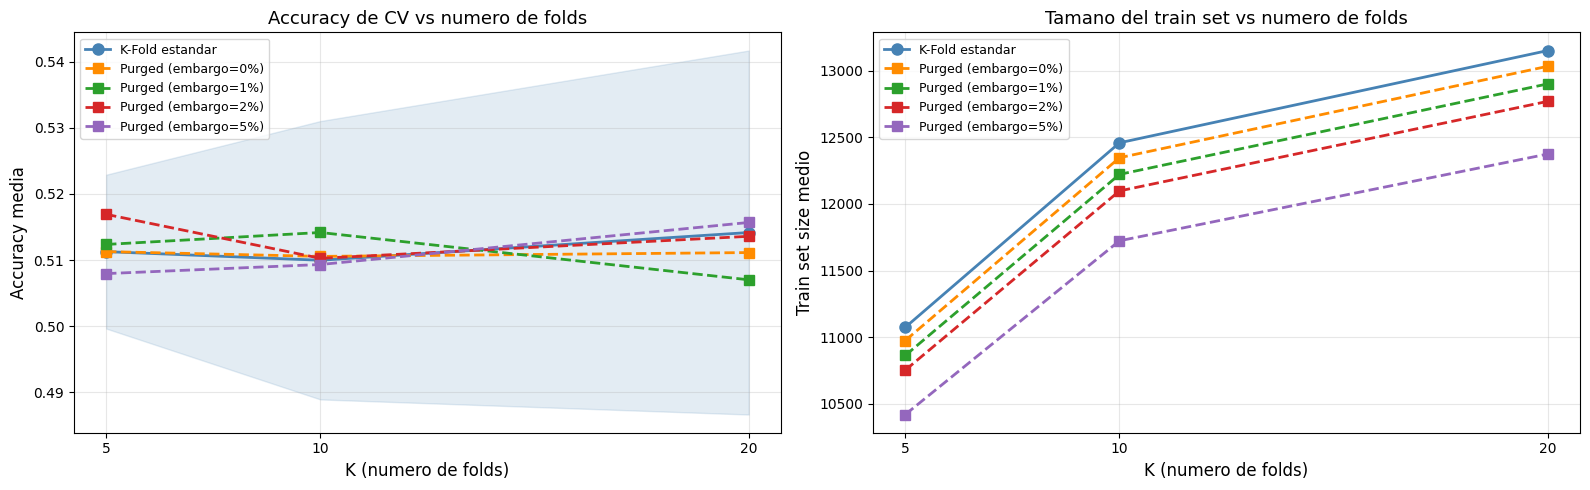

In [ ]:
# --- Grafica 1: Accuracy vs K para K-Fold estandar vs Purged ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izquierdo: Accuracy media
ax = axes[0]
df_std = df_cv_results[df_cv_results["Metodo"] == "K-Fold estandar"]
ax.plot(df_std["K"], df_std["Accuracy media"], "o-", linewidth=2, markersize=8,
        color="steelblue", label="K-Fold estandar")
ax.fill_between(df_std["K"],
                df_std["Accuracy media"] - df_std["Accuracy std"],
                df_std["Accuracy media"] + df_std["Accuracy std"],
                alpha=0.15, color="steelblue")

colors_emb = ["darkorange", "#2ca02c", "#d62728", "#9467bd"]
for i, pct_emb in enumerate(embargo_pcts):
    emb_label = f"{pct_emb:.0%}" if pct_emb > 0 else "0%"
    df_p = df_cv_results[(df_cv_results["Metodo"] == "Purged K-Fold") &
                         (df_cv_results["Embargo"] == emb_label)]
    ax.plot(df_p["K"], df_p["Accuracy media"], "s--", linewidth=2, markersize=7,
            color=colors_emb[i], label=f"Purged (embargo={emb_label})")

ax.set_xlabel("K (numero de folds)", fontsize=12)
ax.set_ylabel("Accuracy media", fontsize=12)
ax.set_title("Accuracy de CV vs numero de folds", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(k_values)

# Panel derecho: Train size medio
ax = axes[1]
ax.plot(df_std["K"], df_std["Train size medio"], "o-", linewidth=2, markersize=8,
        color="steelblue", label="K-Fold estandar")
for i, pct_emb in enumerate(embargo_pcts):
    emb_label = f"{pct_emb:.0%}" if pct_emb > 0 else "0%"
    df_p = df_cv_results[(df_cv_results["Metodo"] == "Purged K-Fold") &
                         (df_cv_results["Embargo"] == emb_label)]
    ax.plot(df_p["K"], df_p["Train size medio"], "s--", linewidth=2, markersize=7,
            color=colors_emb[i], label=f"Purged (embargo={emb_label})")

ax.set_xlabel("K (numero de folds)", fontsize=12)
ax.set_ylabel("Train set size medio", fontsize=12)
ax.set_title("Tamano del train set vs numero de folds", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(k_values)

plt.tight_layout()
plt.show()

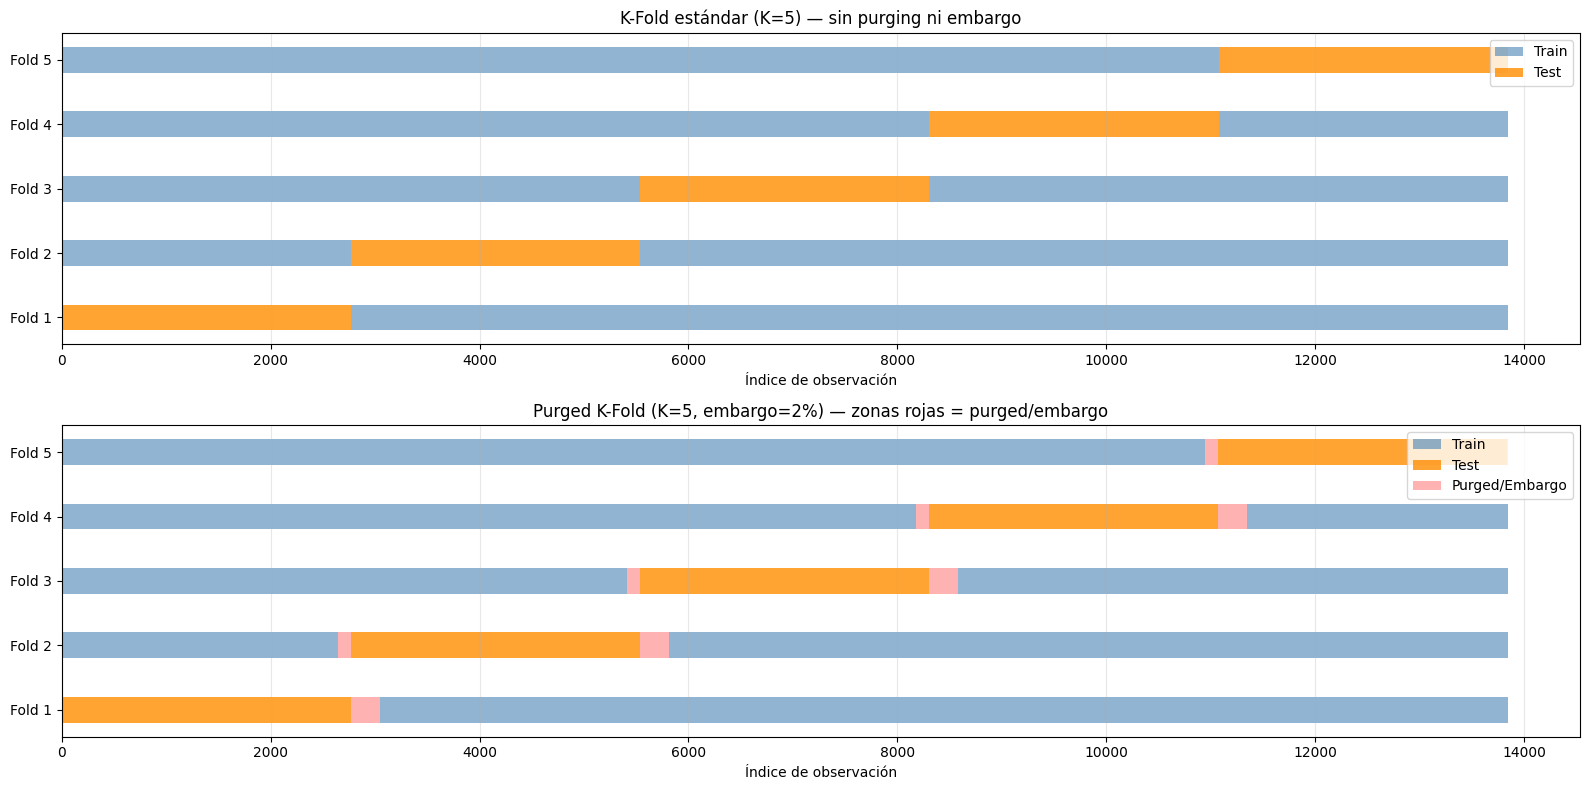

In [ ]:
# --- Gráfica 2: Visualización de splits train/test con purging y embargo ---

def _contiguous_ranges(arr):
    """Devuelve rangos contiguos [(start, end), ...] de un array ordenado."""
    if len(arr) == 0:
        return []
    ranges = []
    start = arr[0]
    prev = arr[0]
    for v in arr[1:]:
        if v != prev + 1:
            ranges.append((start, prev + 1))
            start = v
        prev = v
    ranges.append((start, prev + 1))
    return ranges


fig, axes = plt.subplots(2, 1, figsize=(16, 8))

k_vis = 5
n_vis = len(X_vals)

# K-Fold estándar
ax = axes[0]
kf = KFold(n_splits=k_vis, shuffle=False)
for fold_i, (train_idx, test_idx) in enumerate(kf.split(X_vals)):
    # Train: pintar segmentos antes y después del test
    for start, end in _contiguous_ranges(train_idx):
        ax.barh(fold_i, end - start, left=start, height=0.4, color="steelblue", alpha=0.6)
    # Test
    ax.barh(fold_i, len(test_idx), left=test_idx[0], height=0.4, color="darkorange", alpha=0.8)

ax.set_yticks(range(k_vis))
ax.set_yticklabels([f"Fold {i+1}" for i in range(k_vis)])
ax.set_xlabel("Índice de observación")
ax.set_title(f"K-Fold estándar (K={k_vis}) — sin purging ni embargo", fontsize=12)
# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="steelblue", alpha=0.6, label="Train"),
                   Patch(facecolor="darkorange", alpha=0.8, label="Test")]
ax.legend(handles=legend_elements, loc="upper right")
ax.grid(True, axis="x", alpha=0.3)

# Purged K-Fold con embargo
ax = axes[1]
pct_emb_vis = 0.02
pkf = PurgedKFold(n_splits=k_vis, t1=t1_series, pct_embargo=pct_emb_vis)

for fold_i, (train_idx, test_idx) in enumerate(pkf.split(X_vals)):
    # Colorear train
    for start, end in _contiguous_ranges(train_idx):
        ax.barh(fold_i, end - start, left=start, height=0.4, color="steelblue", alpha=0.6)
    # Colorear test
    ax.barh(fold_i, len(test_idx), left=test_idx[0], height=0.4, color="darkorange", alpha=0.8)
    # Colorear zonas purgadas/embargadas (gaps en train que no son test)
    all_used = set(train_idx) | set(test_idx)
    purged = sorted(set(range(n_vis)) - all_used)
    for start, end in _contiguous_ranges(np.array(purged)):
        ax.barh(fold_i, end - start, left=start, height=0.4, color="red", alpha=0.3)

ax.set_yticks(range(k_vis))
ax.set_yticklabels([f"Fold {i+1}" for i in range(k_vis)])
ax.set_xlabel("Índice de observación")
ax.set_title(f"Purged K-Fold (K={k_vis}, embargo={pct_emb_vis:.0%}) — zonas rojas = purged/embargo", fontsize=12)
legend_elements2 = [Patch(facecolor="steelblue", alpha=0.6, label="Train"),
                    Patch(facecolor="darkorange", alpha=0.8, label="Test"),
                    Patch(facecolor="red", alpha=0.3, label="Purged/Embargo")]
ax.legend(handles=legend_elements2, loc="upper right")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Observaciones sobre la validación cruzada con purging y embargo

**K-Fold estándar vs Purged K-Fold:**
- El **K-Fold estándar** no tiene en cuenta la dependencia temporal entre observaciones. Observaciones del train set que se solapan temporalmente con el test set pueden causar *data leakage*, inflando artificialmente las métricas de rendimiento.
- El **Purged K-Fold** elimina estas observaciones problemáticas, dando una estimación más realista (y típicamente más baja) del rendimiento del modelo.

**Efecto del embargo:**
- Un embargo del 0% solo aplica purging estricto (elimina observaciones con solapamiento directo).
- Embargos del 1-5% añaden un margen de seguridad adicional, eliminando observaciones inmediatamente posteriores al test set que podrían estar correlacionadas por efectos rezagados.
- A mayor embargo, menor tamaño del train set, lo que puede afectar negativamente al rendimiento del modelo si se elimina demasiada información.

**Efecto de K:**
- Con K grande, cada fold de test es más pequeño y hay más folds, dando estimaciones con menor varianza pero potencialmente con más purging relativo.
- Con K pequeño, cada fold es más grande, lo que puede diluir el efecto del purging.

**Implicación práctica:** En datos financieros con dependencia temporal, siempre se debería usar Purged K-Fold (o variantes como Walk-Forward) en lugar de K-Fold estándar para obtener estimaciones honestas del rendimiento out-of-sample.